In [2]:
suppressPackageStartupMessages({
    library(DESeq2)
    library(ggplot2)
    library(rtracklayer)
    library(pheatmap)
    library(RColorBrewer)
    library(ggrepel)
    library(reshape2)
    library(dplyr)
    library(data.table)
    library(tidyr)
    library(ggpubr)
    library(purrr)
    library(ComplexHeatmap)
    
    library(Seurat)
    library(edgeR)
   # library(org.Mm.eg.db)
    })

### Define options

In [3]:
LFC_thr = 2
padj_thr = 0.05

# plot options
options(repr.plot.width=15, repr.plot.height=8) 

#setwd("/Users/tazami/Library/CloudStorage/OneDrive-UniversityofEdinburgh/RNA-seq/STAT3/Bart")


#### Import and prepare data

In [4]:
#Import data
countData <- as.matrix(read.csv('gene_count_matrix_epiblast.csv', row.names = 'gene_id'))
rownames(countData) = rownames(countData) %>% strsplit('[|]') %>% map(2) # change rownames

colData <- read.csv('phenodata_epi2.csv', row.names = 1)
colData$genotype = gsub("-/-", "null", colData$genotype)
colData$group = paste0(colData$genotype, '_',colData$stage)

In [5]:
##Remove ex5.5 results
colData <- colData[colData$stage!="ex5.5",]

#remove samples that are trophoblastic ?

### Also try running with all samples! And possibly find out why E6.5_Stat3null_3 acts strange?

colData <- colData[!rownames(colData) %in% c("E5.5_Stat3null_1", "E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4", "E7.5_WT_3"), ]
colData$genotype <- factor(colData$genotype, levels = c("WT", "Stat3null"))
countData <- countData[, rownames(colData)]
rownames(countData) = make.names(rownames(countData), unique=TRUE)
head(countData)

# Assign Early and late to E6.5 based on PCA
colData = colData %>% as.data.table(keep.rownames=T) %>% 
    setnames('rn', 'sample') %>%
    .[,group_final:=ifelse(genotype=='Stat3null' & stage=='E6.5', ifelse(sample %in% c("E6.5_Stat3null_5", "E6.5_Stat3null_6", "E6.5_Stat3null_7"), 'Stat3null_E6.5_Late', 'Stat3null_E6.5_Early'), group)]

,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,5,11,6,4,48,0,96,94,76,142,⋯,215,235,232,134,170,315,138,178,166,180
Gm18956,4,0,0,0,0,0,0,0,0,0,⋯,3,2,3,0,0,0,4,5,0,0
Gm37686,0,0,0,0,0,0,4,0,0,0,⋯,18,0,27,4,3,10,11,0,0,3
Gm1992,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Gm37329,5,11,20,0,0,0,0,4,13,22,⋯,48,10,9,13,9,0,23,8,18,0
Gm38148,19,23,11,0,7,0,33,57,43,53,⋯,80,6,50,47,25,43,8,36,63,91


In [6]:
##Create a DESeqDataSet from count matrix and labels (DESeqDataSetを作成）

ddsFullE567 <-DESeqDataSetFromMatrix(countData = countData, colData = colData, design = ~ stage + genotype + genotype:stage)  # group
ddsFullE567 <- ddsFullE567[rowSums(counts(ddsFullE567)) > 10, ]
ddsFullE567$genotype <- factor(ddsFullE567$genotype, levels = c("WT","Stat3null"))
ddsFullE567$stage <- factor(ddsFullE567$stage, levels = c("E5.5","E6.5", "E7.5")) # does DESeq just not work with 3 values?

# Normalisation
ddsFullE567 <- estimateSizeFactors(ddsFullE567)
normalized_counts <- counts(ddsFullE567, normalized=TRUE)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


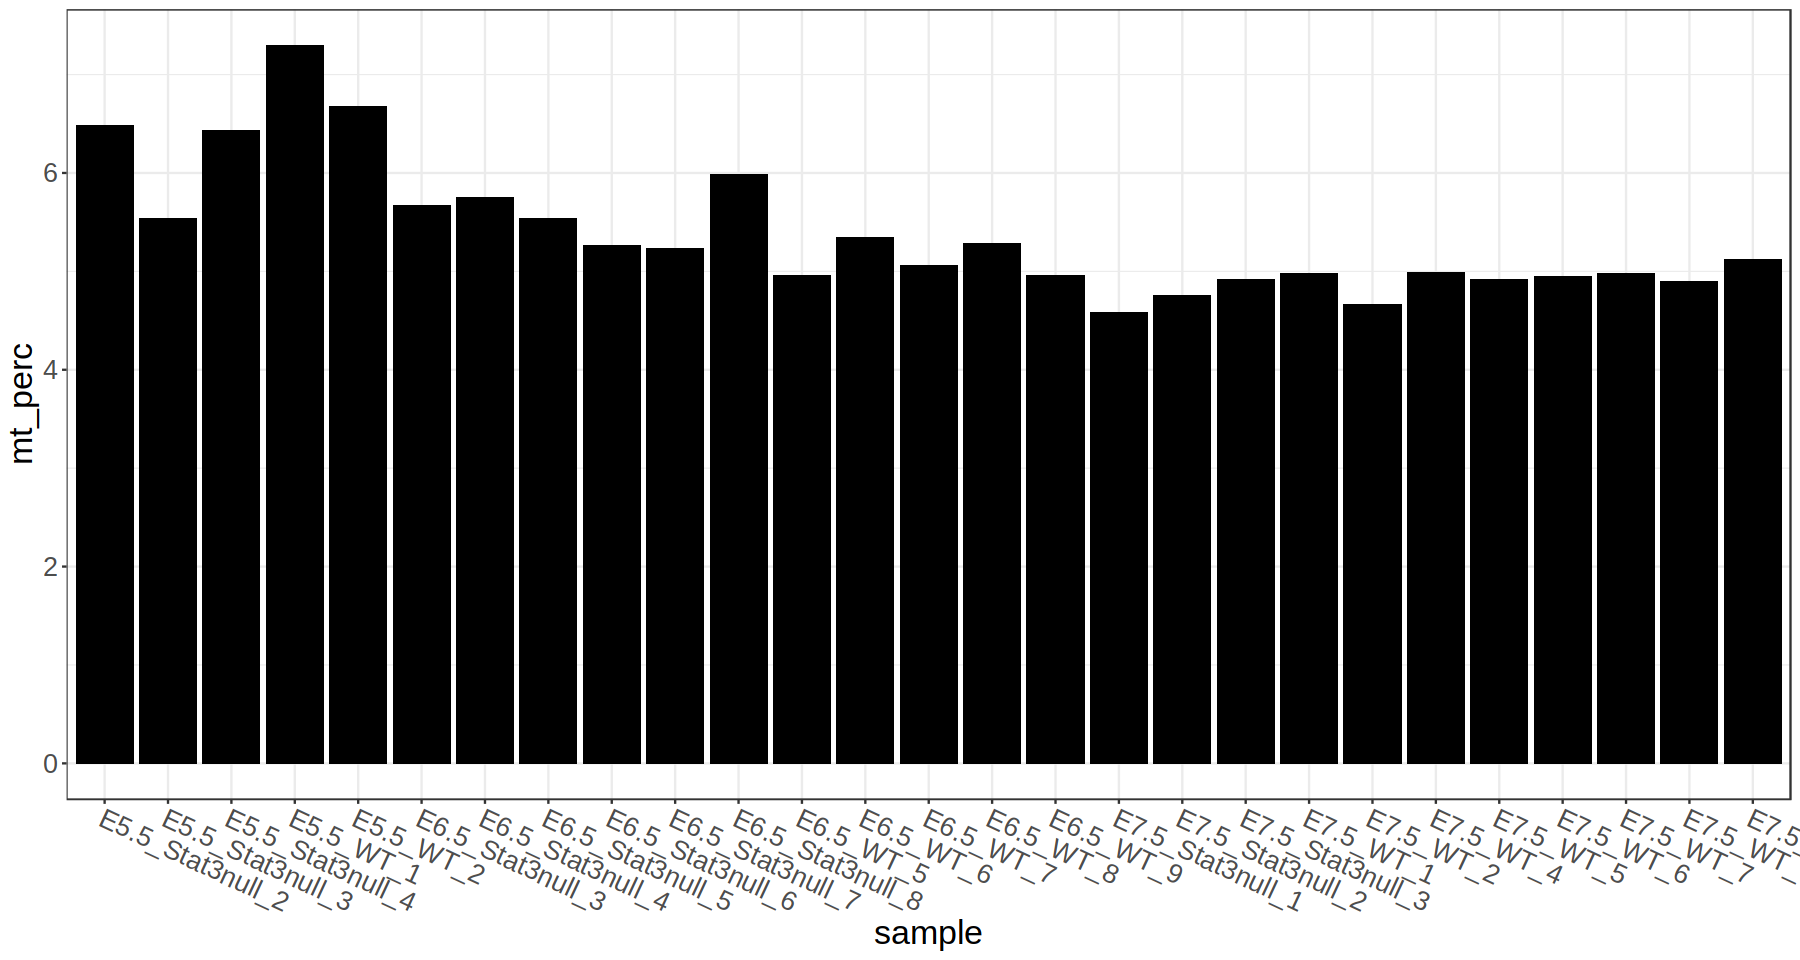

In [7]:
# Check mitochondrial RNA percentage
mt_stats = data.table(sample=colnames(normalized_counts),
                      mt_expr = colSums(normalized_counts[grep('^mt', rownames(normalized_counts)),]),
                        total_expr = colSums(normalized_counts)) %>%
                    .[,mt_perc:=round(mt_expr/total_expr*100,2)]

ggplot(mt_stats, aes(sample, mt_perc)) + geom_bar(stat='identity', fill='black') + theme_bw() + theme(text=element_text(size=20), axis.text.x=element_text(angle=-25, hjust=0, vjust=1))

# Does not seem to vary much by sample

#### Define functions

In [8]:
# Here I define a function to compare conditions, so you can just input condition 1 and 2, and if you're comparing genotype or stage. 
# This is more efficient than copying the entire code for each condition you're testing

compare_conditions = function(condition1, condition2, compare_var='genotype', padj_thr=0.05, LFC_thr=2, group_final=TRUE){#, lfc_thr = 1, shrink_lfc=FALSE){
   # Select only samples that are in the 2 conditions you're testing 
    # group_final defines if we want to separate Stat3null E6.5 by early and late
    if(group_final==TRUE){
       colData_tmp <- colData[group_final %in% c(condition1, condition2)]
    }else{ 
        colData_tmp <- colData[group %in% c(condition1, condition2)]
    }
    
    countData_tmp <- countData[, colData_tmp$sample]

    ##Create a DESeqDataSet from count matrix and labels
    if(compare_var=='genotype'){
        dds_tmp <- suppressMessages(DESeqDataSetFromMatrix(countData = countData_tmp, colData = colData_tmp, design = ~  genotype))  # group
    }else if(compare_var=='stage'){
        dds_tmp <- suppressMessages(DESeqDataSetFromMatrix(countData = countData_tmp, colData = colData_tmp, design = ~  stage))  # group
    }else{print('compare var not found')}
    
    # remove non-expressed genes to get higher p values
    dds_tmp <- dds_tmp[rowSums(counts(dds_tmp)) > 10, ] 
    dds_tmp$genotype <- factor(dds_tmp$genotype, levels = c("WT","Stat3null"))

    # Normalisation
    dds_tmp <- estimateSizeFactors(dds_tmp)
    #normalized_counts_tmp <- counts(dds_tmp, normalized=TRUE)

    # Run DESeq
    deseq = suppressMessages(DESeq(dds_tmp))
    
    # get the results
    if(compare_var=='genotype'){
        result = suppressMessages(results(deseq, 
                      contrast = c('genotype', "Stat3null", "WT")))
    }else if(compare_var=='stage'){
         result = suppressMessages(results(deseq, 
                       contrast = c('stage', strsplit(condition1, '_') %>% map_chr(2), strsplit(condition2, '_') %>% map_chr(2))))
    }         
        
    # if(shrink_lfc==TRUE){
    #     result = lfcShrink(deseq, 
    #                        coef=resultsNames(deseq)[2], 
    #                        res=result,
    #                        lfcThreshold=lfc_thr) %>% 
    #                 as.data.table(., keep.rownames=T) %>% 
    #                 setnames('rn', 'gene') %>%
    #                 .[, sig:=padj <= padj_thr & abs(log2FoldChange) >= LFC_thr & !is.na(padj)] %>%
    #                 .[,condition:=paste0(condition1, '_', condition2)]  
    # }else{
        
        # Write results to nicer data.table output format
        # if you want the raw output from DESeq's result command, remove the code below
        result = result %>% 
                    as.data.table(., keep.rownames=T) %>% 
                    setnames('rn', 'gene') %>%
                    .[, sig:=padj <= padj_thr & abs(log2FoldChange) >= LFC_thr & !is.na(padj)] %>%
                    .[,condition:=paste0(condition1, '_', condition2)]  
    #}
        
    return(result)
}

In [9]:
# Function to plot volcano plots based on output of compare_conditions
plot_volcano = function(res, padj_thr=1e-15, flc_thr = 10){
    res = res[!is.na(padj)]
    res = res[,padj:=ifelse(padj<padj_thr, padj_thr, padj)] %>%
             .[,log2FoldChange:=ifelse(log2FoldChange<=-flc_thr, -flc_thr, ifelse(log2FoldChange>=flc_thr, flc_thr, log2FoldChange))]
    labels = rbind(res[sig==TRUE,] %>% .[order(-log2FoldChange),] %>% .[,head(.SD, 15)], res[sig==TRUE,] %>% .[order(log2FoldChange),] %>% .[,head(.SD, 15)])

    p = ggplot(res, aes(log2FoldChange, -log10(padj), col=sig)) + 
        geom_point() + 
        xlim(-max(abs(res$log2FoldChange)), max(abs(res$log2FoldChange))) + 
        scale_color_manual(values=c('black', 'red')) +
        ggrepel::geom_text_repel(data=labels, aes(x=log2FoldChange, y=-log10(padj+1e-100), label=gene), 
                                 max.overlaps=Inf, size=4, col='black') +
        geom_vline(xintercept=0, color='red', linetype='dotted', size=2) + 
        theme_bw() +
        theme(text=element_text(size=15),
             legend.position='none') + 
        ggtitle(paste0('Comparison: ', res$condition))
    return(p)
}

In [10]:
# Function to plot heatmap containing input genes and samples
plot_heatmap = function(genes, samples=colnames(normalized_counts), title=NULL){

    # heatmap
    heatmap.mtx = normalized_counts[genes, samples]
#    heatmap.mtx[rowSums(heatmap.mtx)>1,]
    heatmap_scaled.mtx <- t(scale(t(heatmap.mtx)))

    #genes = to.plot_tmp[order(abs(log2FoldChange)),]$gene %>% head(15)
    #genelabs <- rowAnnotation(Genes = anno_mark(at=which(rownames(heatmap_scaled.mtx) %in% genes), labels = rownames(heatmap_scaled.mtx)[which(rownames(heatmap_scaled.mtx) %in% genes)]))

    #top annotation
    anno <- HeatmapAnnotation(df=colData(ddsFullE567)[samples, c("genotype", "stage")], 
                              col = list(genotype=c("WT"="#00afbb", "Stat3null"="#fc4e07"), 
                                         stage=c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")),
                              annotation_legend_param = list(title_gp = gpar(fontsize = 12),
                                                             labels_gp = gpar(fontsize = 12)))
    
    options(repr.plot.width=20, repr.plot.height=8) 

    hm = Heatmap(heatmap_scaled.mtx,
            column_title = title,
            name = "z-score", 
            top_annotation=anno,
            row_gap = unit(1, "mm"), 
            column_gap = unit(1, "mm"), 
            border = TRUE, 
            row_title_gp = gpar(fontsize = 12),
            row_names_gp = gpar(fontsize = 10), 
            column_title_gp = gpar(fontsize = 12), 
            column_names_gp = gpar(fontsize = 10),
            heatmap_legend_param = list(title_gp=gpar(fontsize = 12),
            labels_gp=gpar(fontsize = 12)))
    draw(hm)
}

In [11]:
plot_go = function(up_genes=NULL, down_genes=NULL, ont='BP', top_n=10, title=NULL){
    suppressPackageStartupMessages({library(topGO)})
    if(length(up_genes[up_genes>0])>1){
        geneList = up_genes
                GOdata <- new("topGOdata",
                    ontology = ont,
                    allGenes = geneList,  #geneSel = DEGs,
                    geneSelectionFun = function(x)x,
                    annot = annFUN.org, mapping = "org.Mm.eg.db")
                resultFisher <- runTest(GOdata, algorithm = "elim", statistic = "fisher")

                up_GO = GenTable(GOdata, raw.p.value = resultFisher, topNodes = length(resultFisher@score),
                        numChar = 120) %>% as.data.table() %>% .[order(as.numeric(raw.p.value))] %>%  head(top_n) %>% .[,Term:=factor(Term, levels=rev(Term))]

                GO_plot_up = ggplot(up_GO, aes(Term, -log10(as.numeric(raw.p.value)))) +
                    geom_bar(stat='identity', col='black', fill='darkred') + 
                    geom_text(aes(label=Significant),color="white",size=10,position=position_stack(vjust=0.9)) +
                    coord_flip() + 
                    ggtitle(paste0('up: ', length(up_genes[up_genes>0]), ' genes')) +
                    theme_bw() + 
                    xlab('-log10(P-value)') + 
                    theme(text=element_text(size=20),
                         legend.position='none',
                         axis.title.y=element_blank(),
                         axis.text.y=element_text(color='black'),
                     #    axis.title.x=element_blank(),
                         plot.title = element_text(hjust = 0.5))
    }
        
    if(length(down_genes[down_genes>0])>1){
        geneList = down_genes
                GOdata <- new("topGOdata",
                    ontology = ont,
                    allGenes = geneList,  #geneSel = DEGs,
                    geneSelectionFun = function(x)x,
                    annot = annFUN.org, mapping = "org.Mm.eg.db")
                resultFisher <- runTest(GOdata, algorithm = "elim", statistic = "fisher")

                down_GO = GenTable(GOdata, raw.p.value = resultFisher, topNodes = length(resultFisher@score),
                        numChar = 120) %>% as.data.table() %>% .[order(as.numeric(raw.p.value))] %>%  head(top_n) %>% .[,Term:=factor(Term, levels=rev(Term))]

                GO_plot_down = ggplot(down_GO, aes(Term, -log10(as.numeric(raw.p.value)))) +
                    geom_bar(stat='identity', col='black', fill='darkblue') + 
                    geom_text(aes(label=Significant),color="white",size=10,position=position_stack(vjust=0.9)) +
                    coord_flip() + 
                    ggtitle(paste0('down: ', length(down_genes[down_genes>0]), ' genes')) +
                    theme_bw() + 
                    xlab('-log10(P-value)') + 
                    theme(text=element_text(size=20),
                         legend.position='none',
                         axis.title.y=element_blank(),
                         axis.text.y=element_text(color='black'),
                     #    axis.title.x=element_blank(),
                         plot.title = element_text(hjust = 0.5))
    }
    
    if(length(up_genes)>1 & length(down_genes)>1){
        options(repr.plot.width=25, repr.plot.height=8) 
    annotate_figure(ggarrange(GO_plot_up, 
                      GO_plot_down,
                      nrow=1), 
                    top = text_grob(paste0(title), , size = 25))
    }else if(length(up_genes)>1){
        options(repr.plot.width=12.5, repr.plot.height=8) 
         annotate_figure(GO_plot_up, 
                    top = text_grob(paste0(title), , size = 25))
    }else if(length(down_genes)>1){
        options(repr.plot.width=12.5, repr.plot.height=8) 
         annotate_figure(GO_plot_down, 
                    top = text_grob(paste0(title), , size = 25))
    }
}

# Comparing Stat3 with WT of similar developmental progression

In [12]:
test = compare_conditions(condition1='WT_E5.5' , condition2='Stat3null_E5.5', compare_var='genotype')


Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [18]:
# Run analysis between WT and Stat3null of comparable development
wt55_vs_ko65early = compare_conditions(condition1='WT_E5.5' , condition2='Stat3null_E6.5_Early', compare_var='genotype')
wt65_vs_ko65late = compare_conditions(condition1='WT_E6.5' , condition2='Stat3null_E6.5_Late', compare_var='genotype')
wt65_vs_ko75 = compare_conditions(condition1='WT_E6.5' , condition2='Stat3null_E7.5', compare_var='genotype')

# Could also include WT_E5.5 vs Stat3_E5.5 since they look very similar transcriptomically

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”
Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


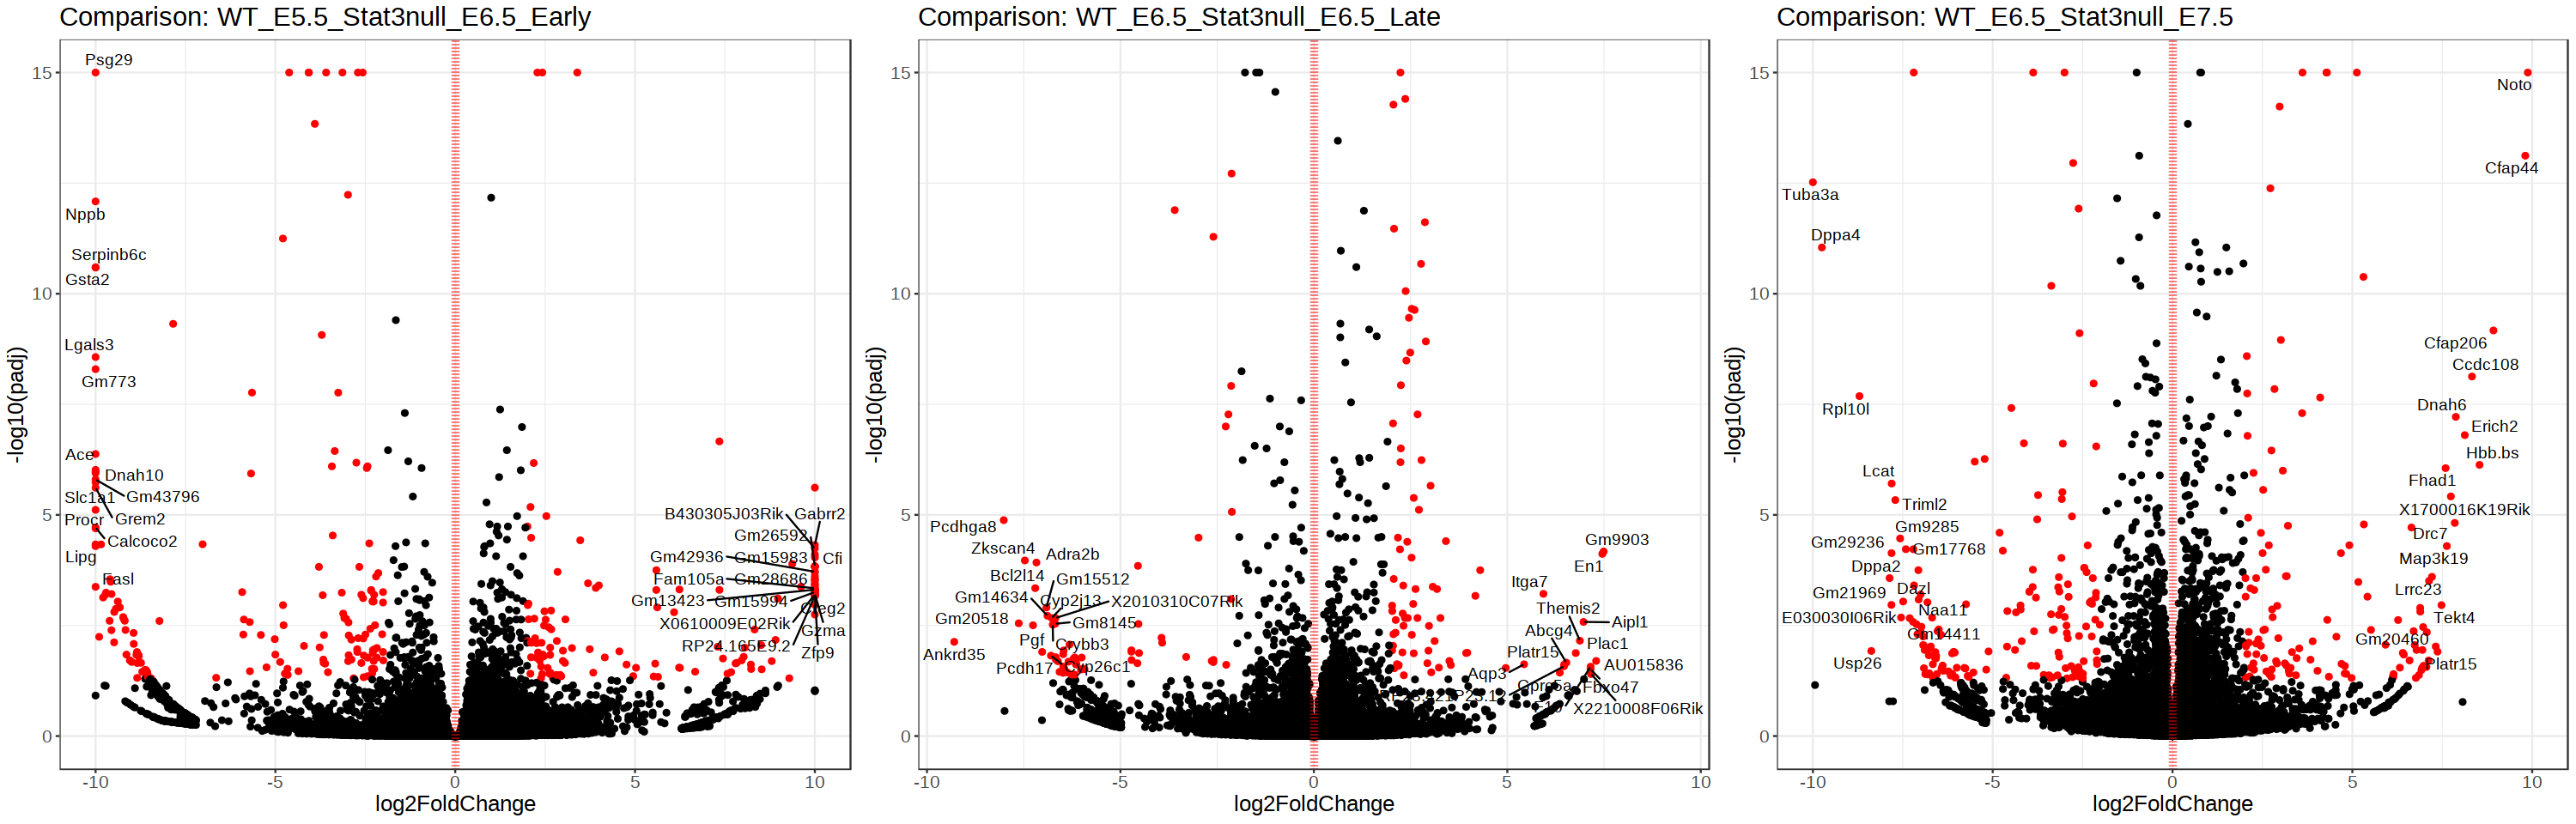

In [12]:
options(repr.plot.width=25, repr.plot.height=8) 

ggarrange(plot_volcano(wt55_vs_ko65early),
          plot_volcano(wt65_vs_ko65late),
          plot_volcano(wt65_vs_ko75),
         nrow=1)


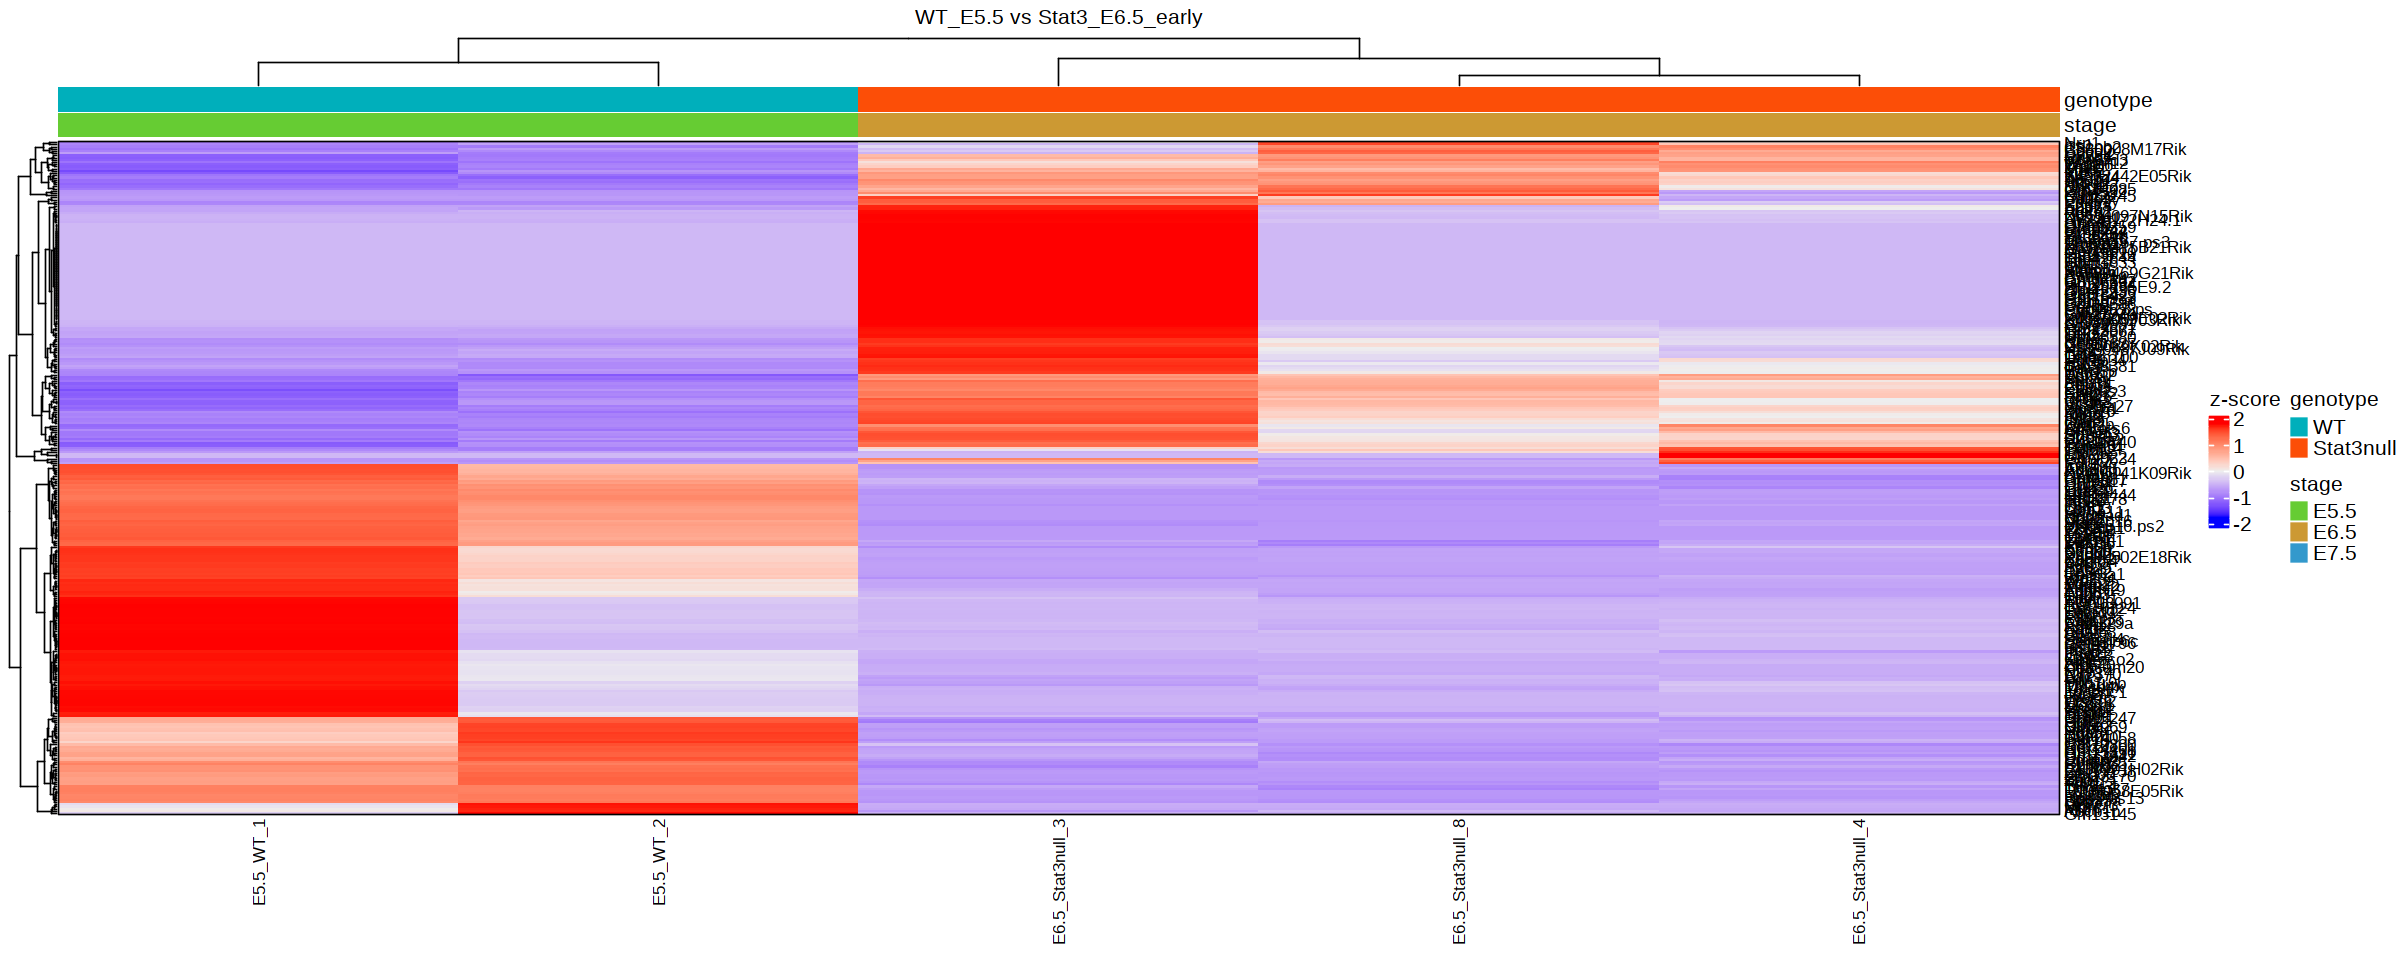

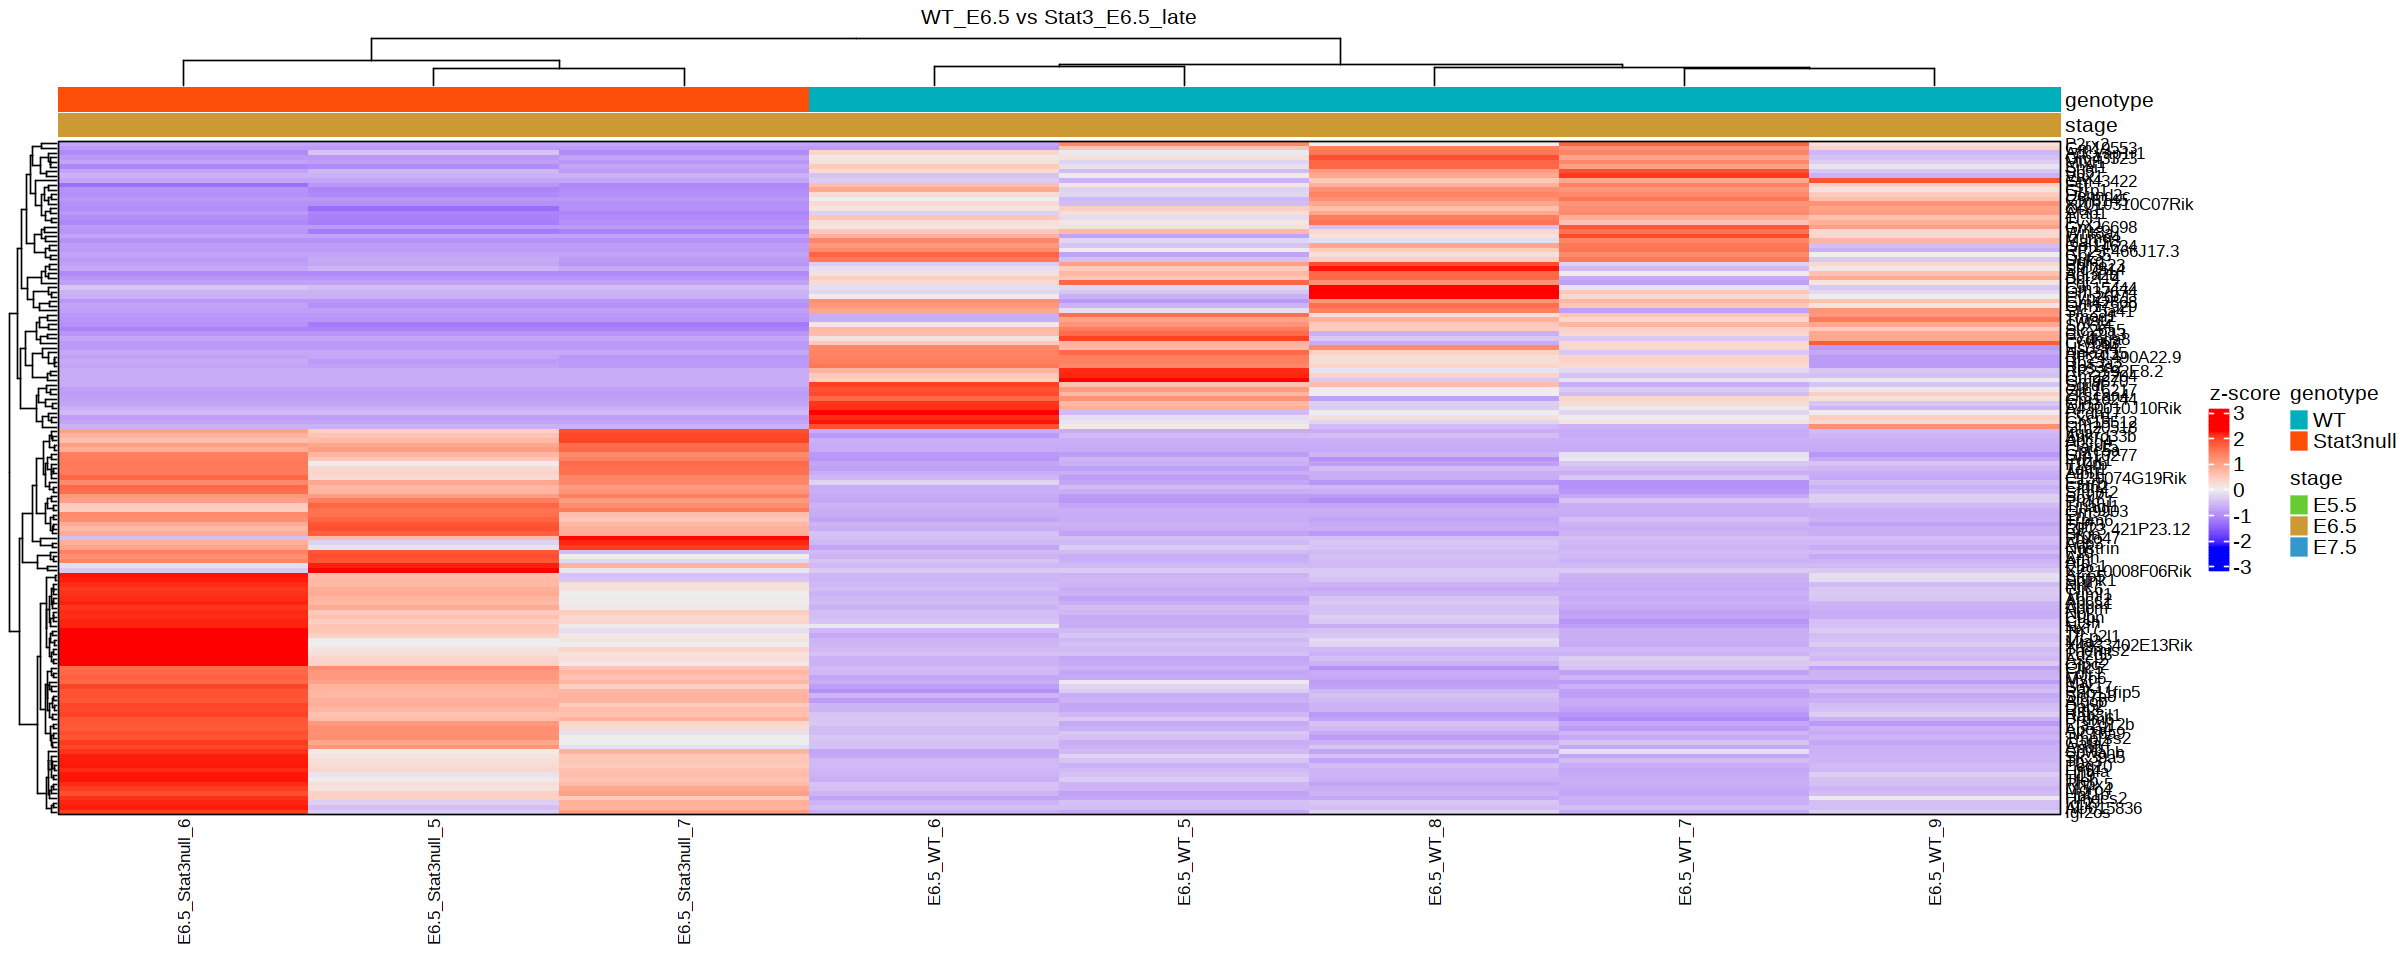

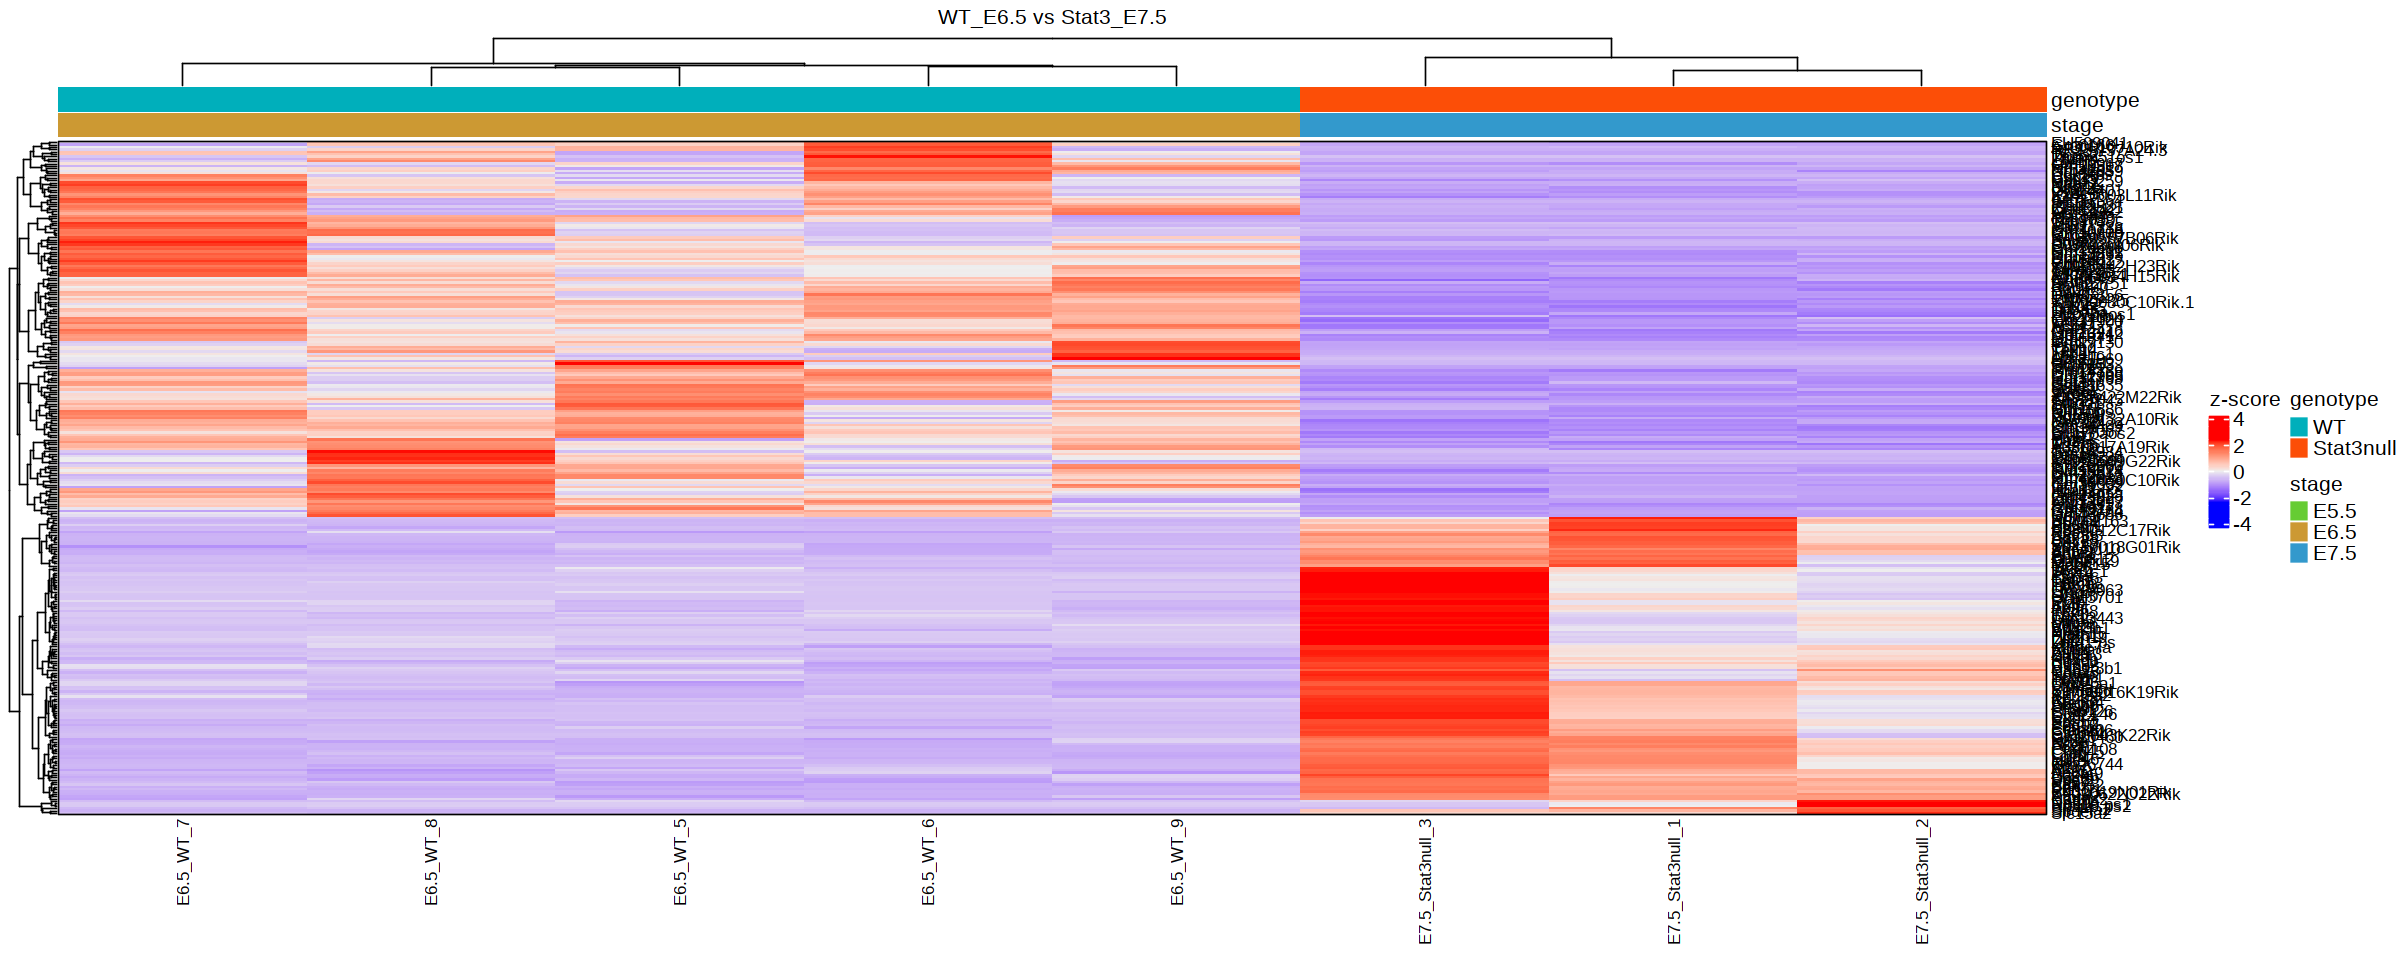

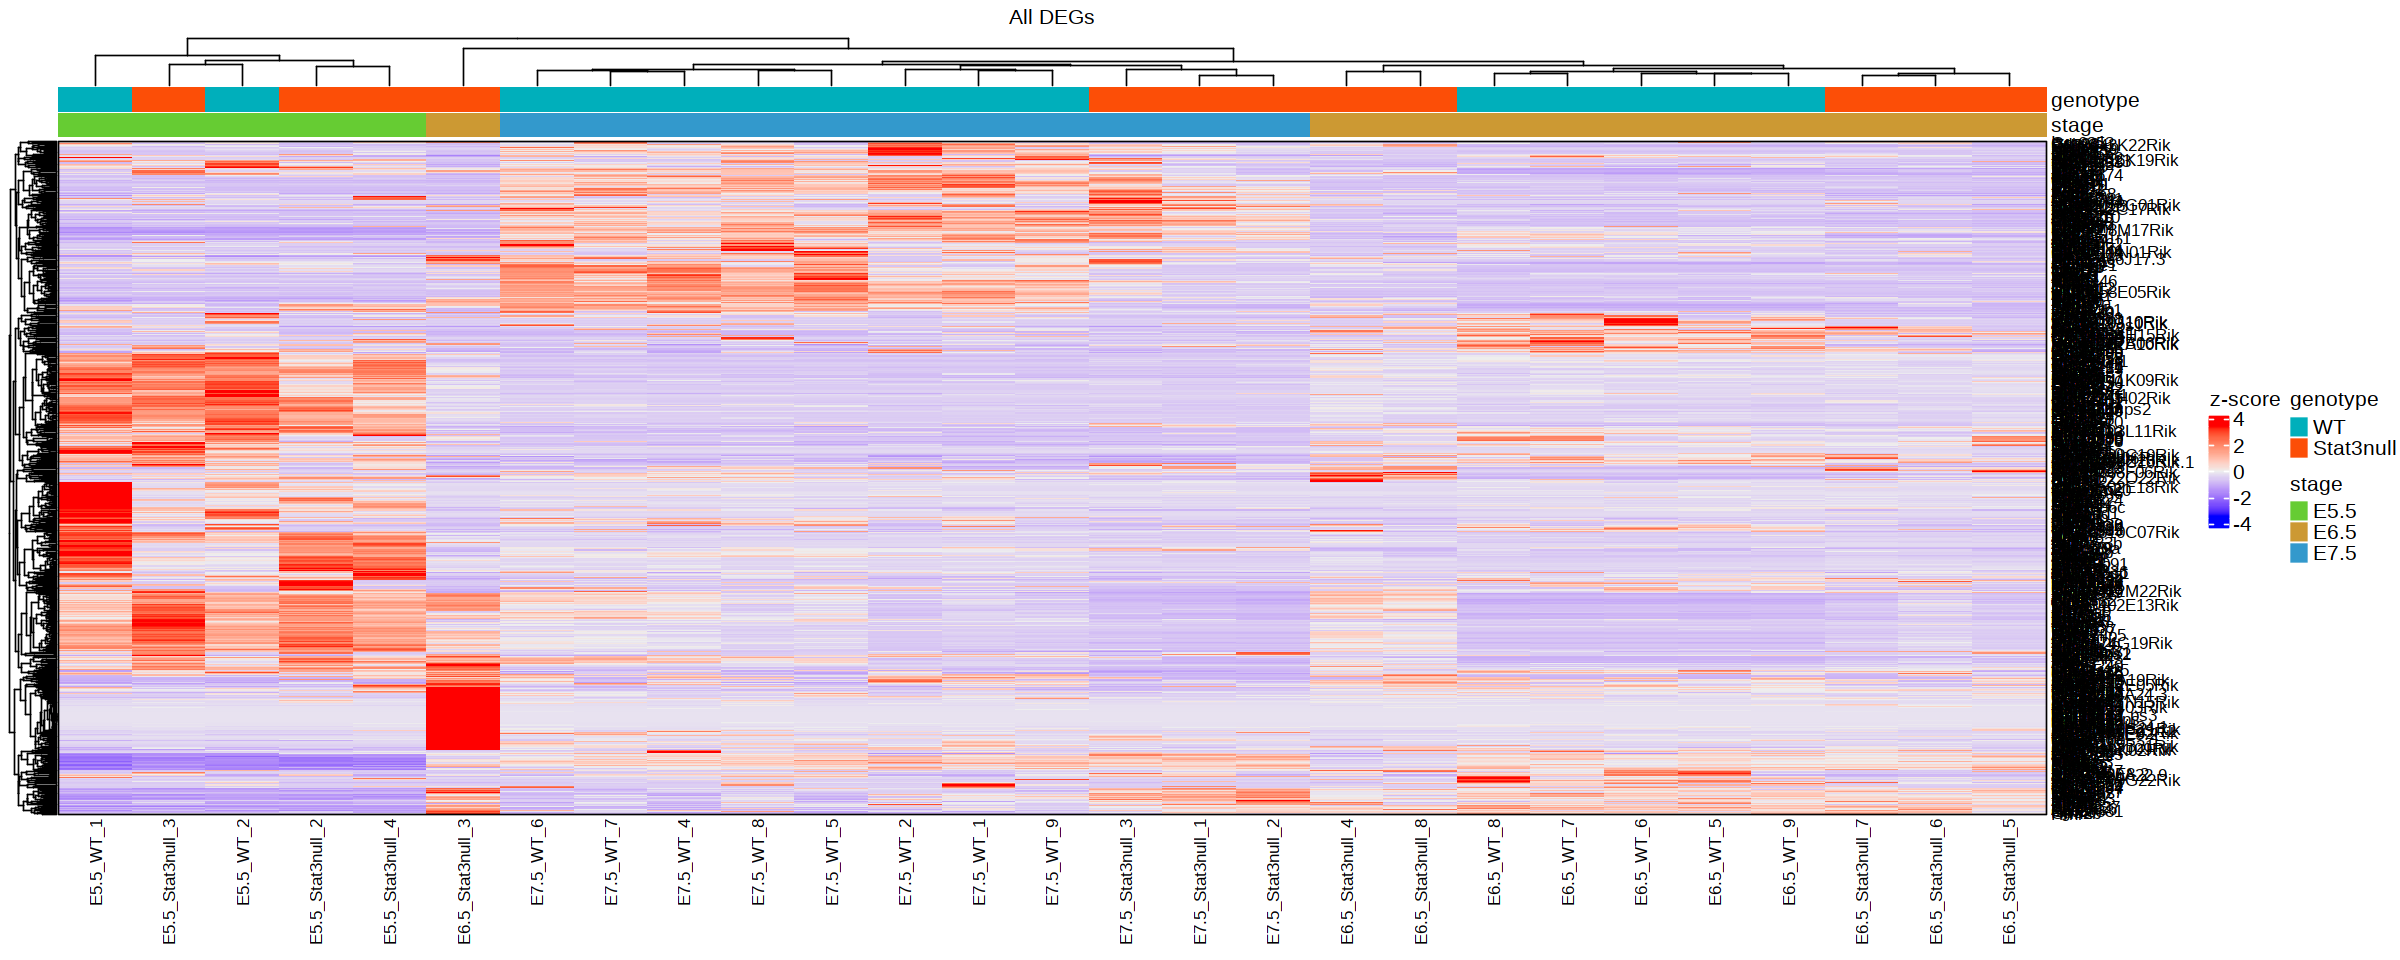

In [21]:
# Plot heatmaps
samples_i = colData[group_final %in% c('Stat3null_E6.5_Early','WT_E5.5'), sample]
plot_heatmap(wt55_vs_ko65early[sig==TRUE, gene], samples_i, title='WT_E5.5 vs Stat3_E6.5_early')

samples_i = colData[group_final %in% c('Stat3null_E6.5_Late','WT_E6.5'), sample]
plot_heatmap(wt65_vs_ko65late[sig==TRUE, gene], samples_i, title='WT_E6.5 vs Stat3_E6.5_late')

samples_i = colData[group_final %in% c('Stat3null_E7.5','WT_E6.5'), sample]
plot_heatmap(wt65_vs_ko75[sig==TRUE, gene], samples_i, title='WT_E6.5 vs Stat3_E7.5')

all_genes = c(wt55_vs_ko65early[sig==TRUE, gene], wt65_vs_ko65late[sig==TRUE, gene], wt65_vs_ko75[sig==TRUE, gene])
plot_heatmap(all_genes, title='All DEGs')

'select()' returned 1:1 mapping between keys and columns

Warning message:
“package ‘graph’ was built under R version 4.1.2”
'select()' returned 1:1 mapping between keys and columns



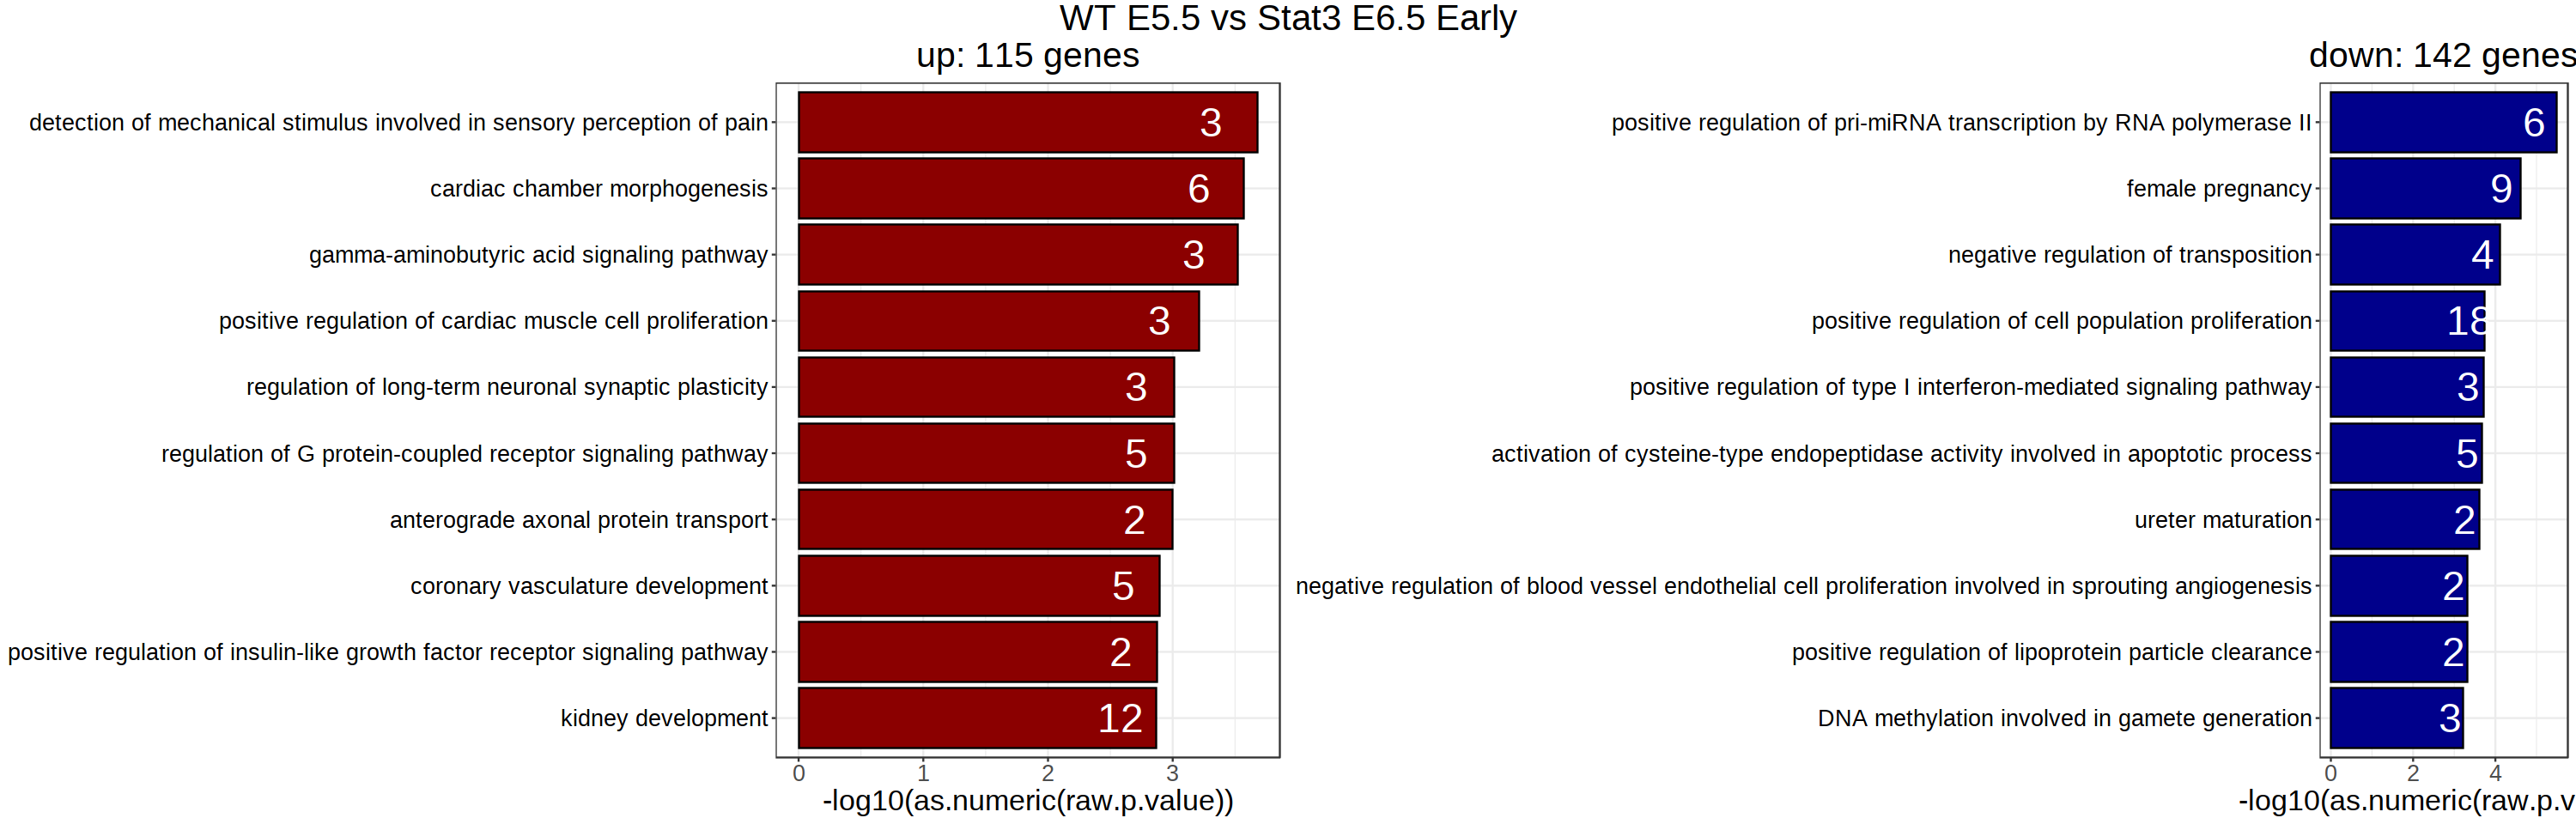

'select()' returned 1:1 mapping between keys and columns



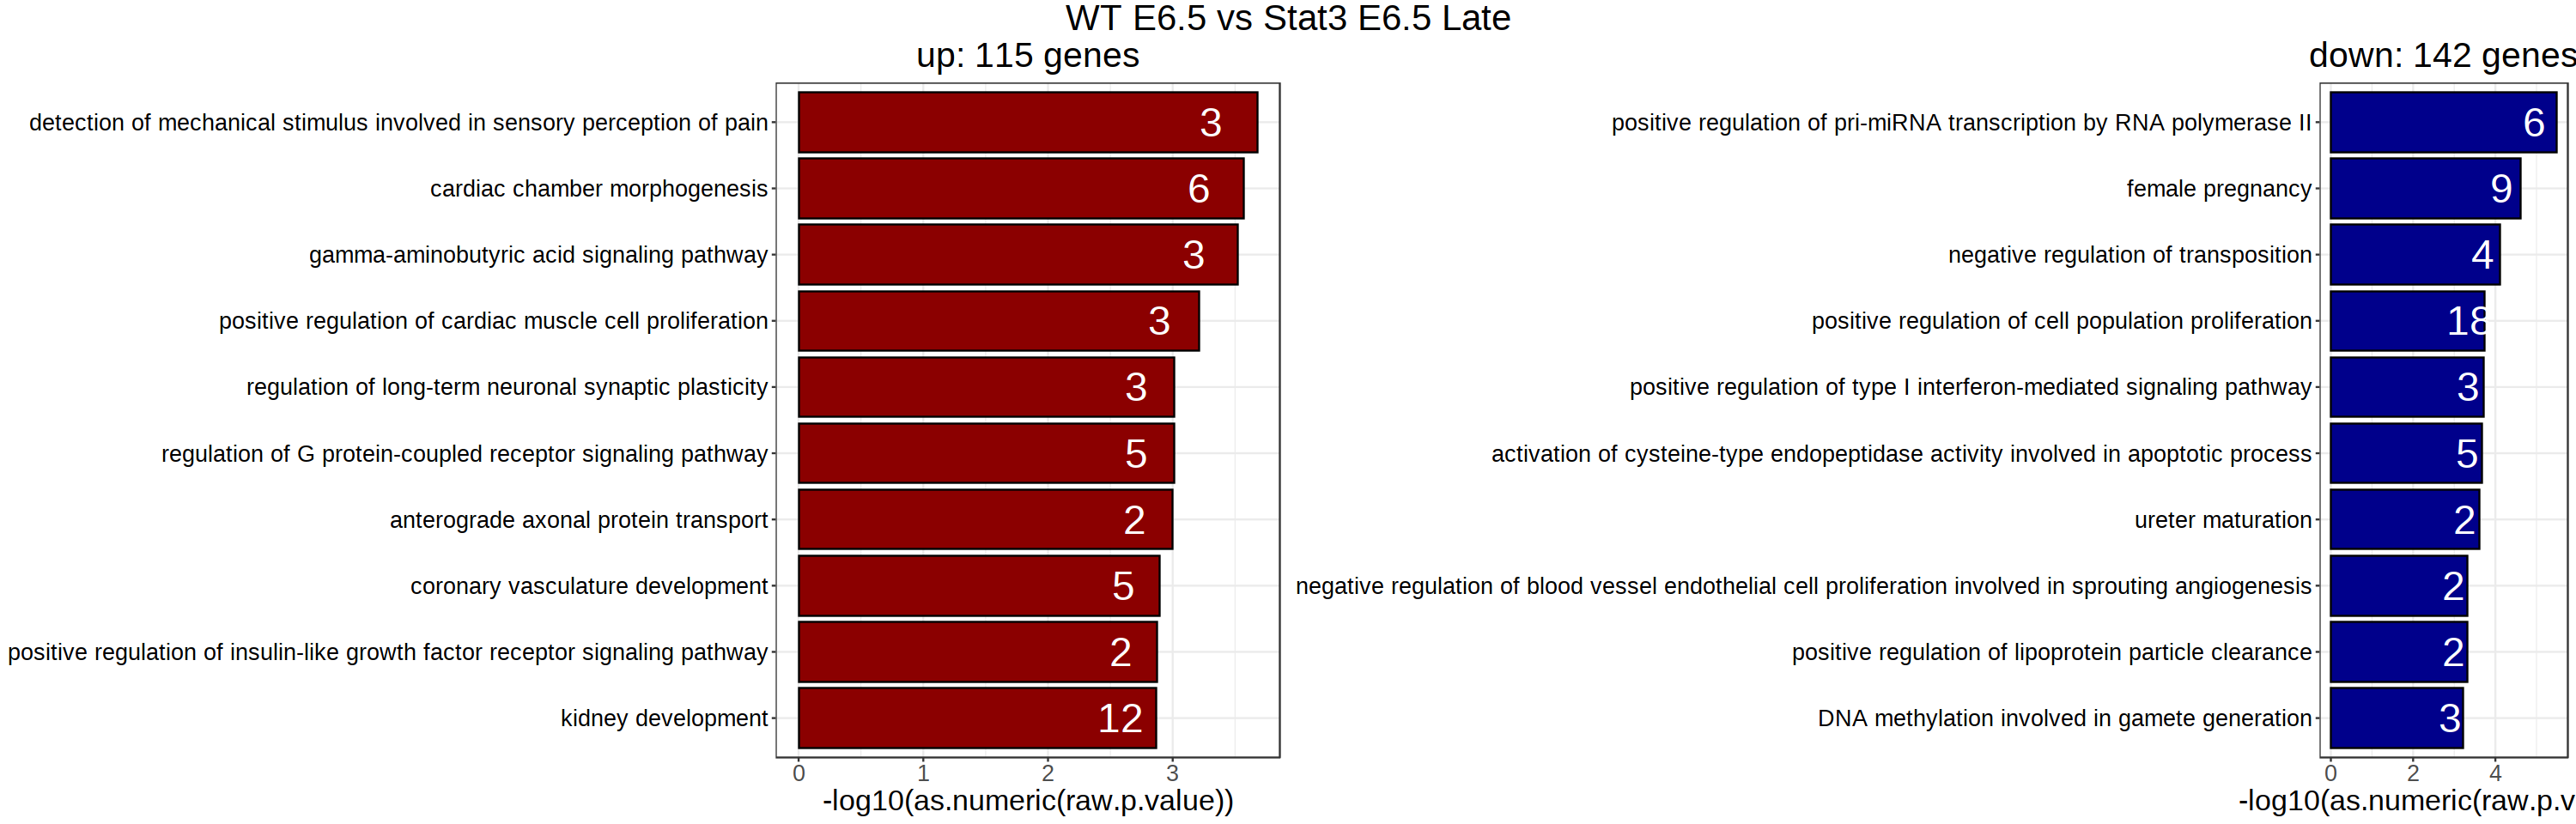

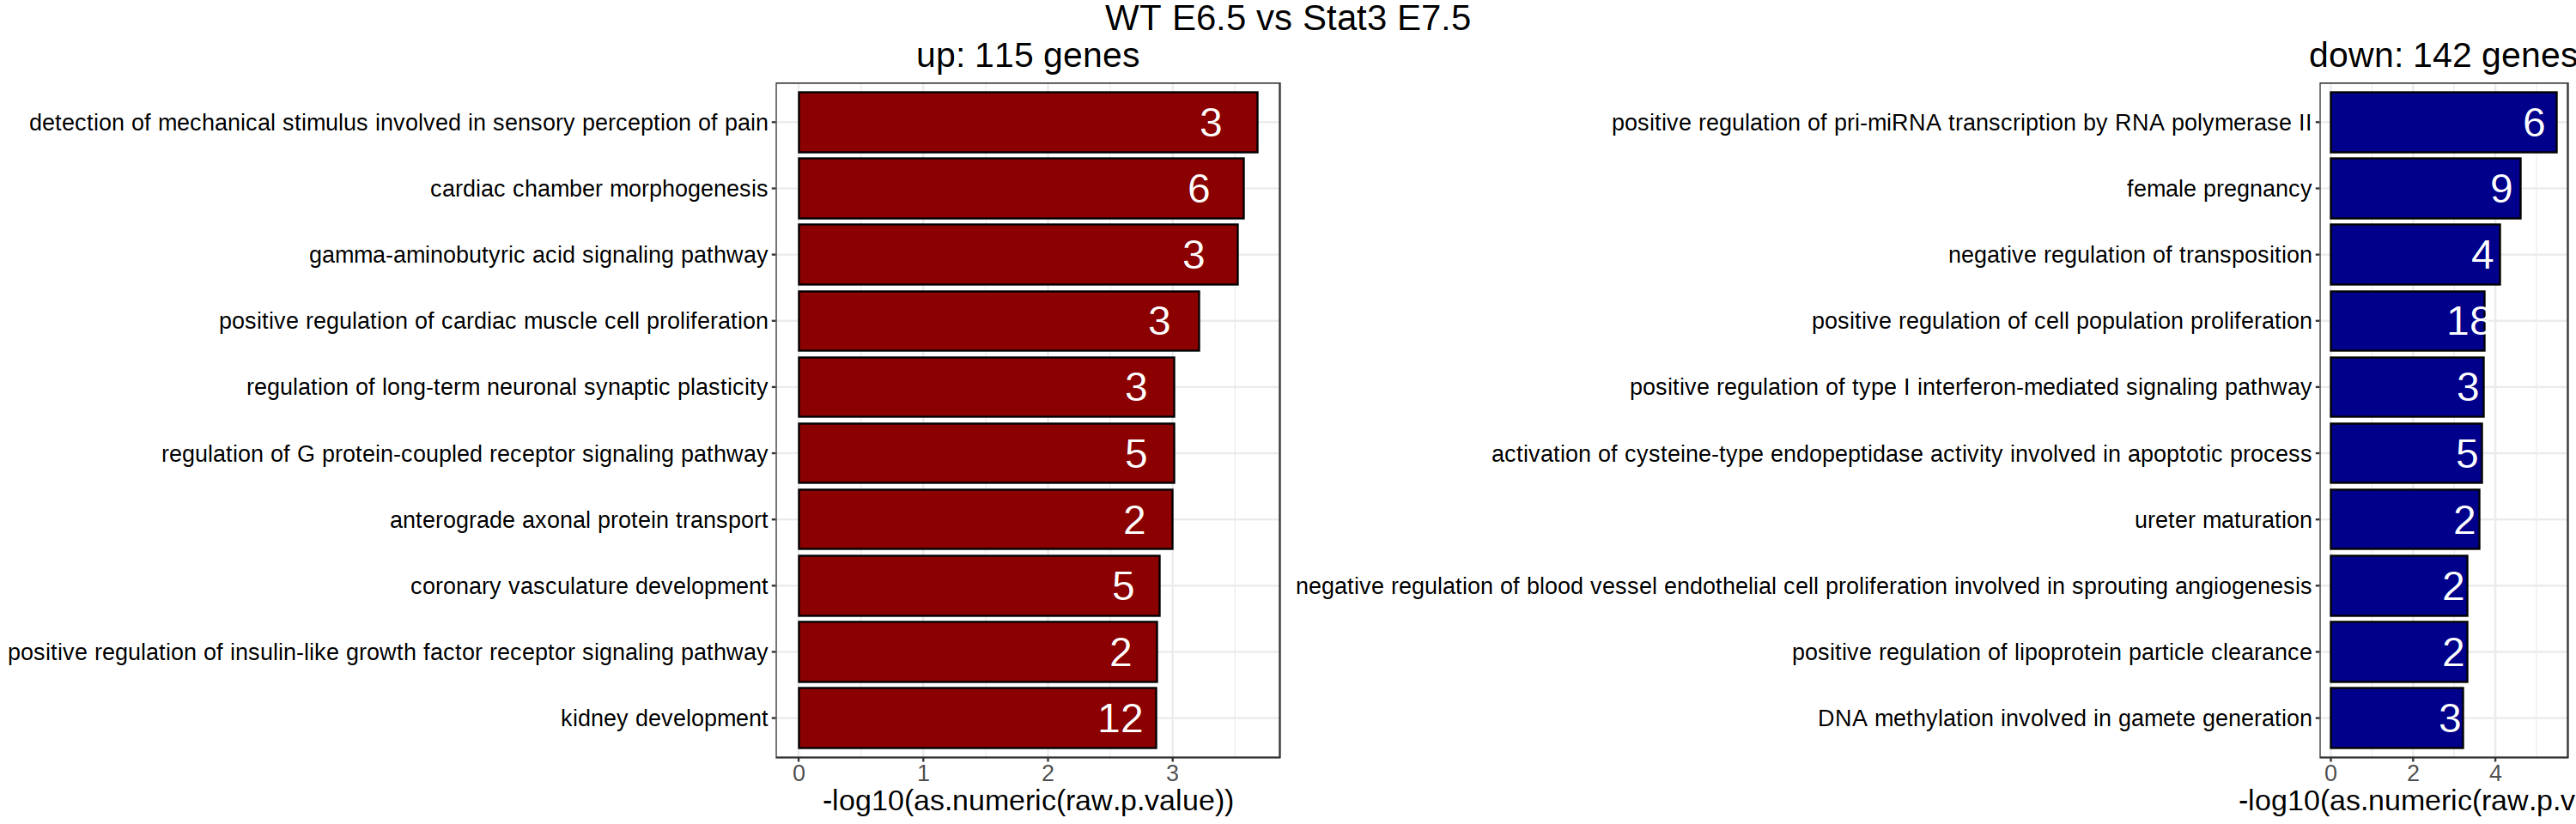

In [24]:
test = wt55_vs_ko65early %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig==TRUE & log2FoldChange>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig==TRUE & log2FoldChange<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='WT E5.5 vs Stat3 E6.5 Early', ont='BP'))

test = wt55_vs_ko65early %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig==TRUE & log2FoldChange>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig==TRUE & log2FoldChange<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='WT E6.5 vs Stat3 E6.5 Late', ont='BP'))

test = wt55_vs_ko65early %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig==TRUE & log2FoldChange>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig==TRUE & log2FoldChange<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='WT E6.5 vs Stat3 E7.5', ont='BP'))

# James Briscoe's suggestion

In [ ]:

# Run analysis between WT stages
wt65_vs_wt55 = compare_conditions(condition1='WT_E6.5' , condition2='WT_E5.5', compare_var='stage')
wt75_vs_wt65 = compare_conditions(condition1='WT_E7.5' , condition2='WT_E6.5', compare_var='stage')

# Run analysis between stat3null stages
stat65_vs_stat55 = compare_conditions(condition1='Stat3null_E6.5' , condition2='Stat3null_E5.5', compare_var='stage',group_final=FALSE)
stat75_vs_stat65 = compare_conditions(condition1='Stat3null_E7.5' , condition2='Stat3null_E6.5', compare_var='stage',group_final=FALSE)

In [ ]:
ggarrange(plot_volcano(wt65_vs_wt55, padj_thr=1e-35, flc_thr = 12),
          plot_volcano(wt75_vs_wt65, padj_thr=1e-35, flc_thr = 12),
         nrow=1, ncol=3)

ggarrange(plot_volcano(stat65_vs_stat55, padj_thr=1e-35, flc_thr = 12),
          plot_volcano(stat75_vs_stat65, padj_thr=1e-35, flc_thr = 12),
         nrow=1, ncol=3)

In [44]:
development_genes = unique(c(wt75_vs_wt65[sig==TRUE, gene], wt65_vs_wt55[sig==TRUE, gene]))
stat3_genes = unique(c(stat75_vs_stat65[sig==TRUE, gene], stat65_vs_stat55[sig==TRUE, gene]))

In [45]:
print(paste0('genes diff over stages in wt: ', length(development_genes)))
print(paste0('genes diff over stages in stat3null: ', length(stat3_genes)))
print(paste0('genes in both: ', length(intersect(development_genes, stat3_genes))))
print(paste0('genes only in stat3null: ', length(stat3_genes) -  length(intersect(development_genes, stat3_genes))))

[1] "genes diff over stages in wt: 3156"
[1] "genes diff over stages in stat3null: 1082"
[1] "genes in both: 677"
[1] "genes only in stat3null: 405"


In [46]:
stat3_specific = setdiff(stat3_genes, development_genes)
#dev_specific = setdiff(development_genes, stat3_genes)

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



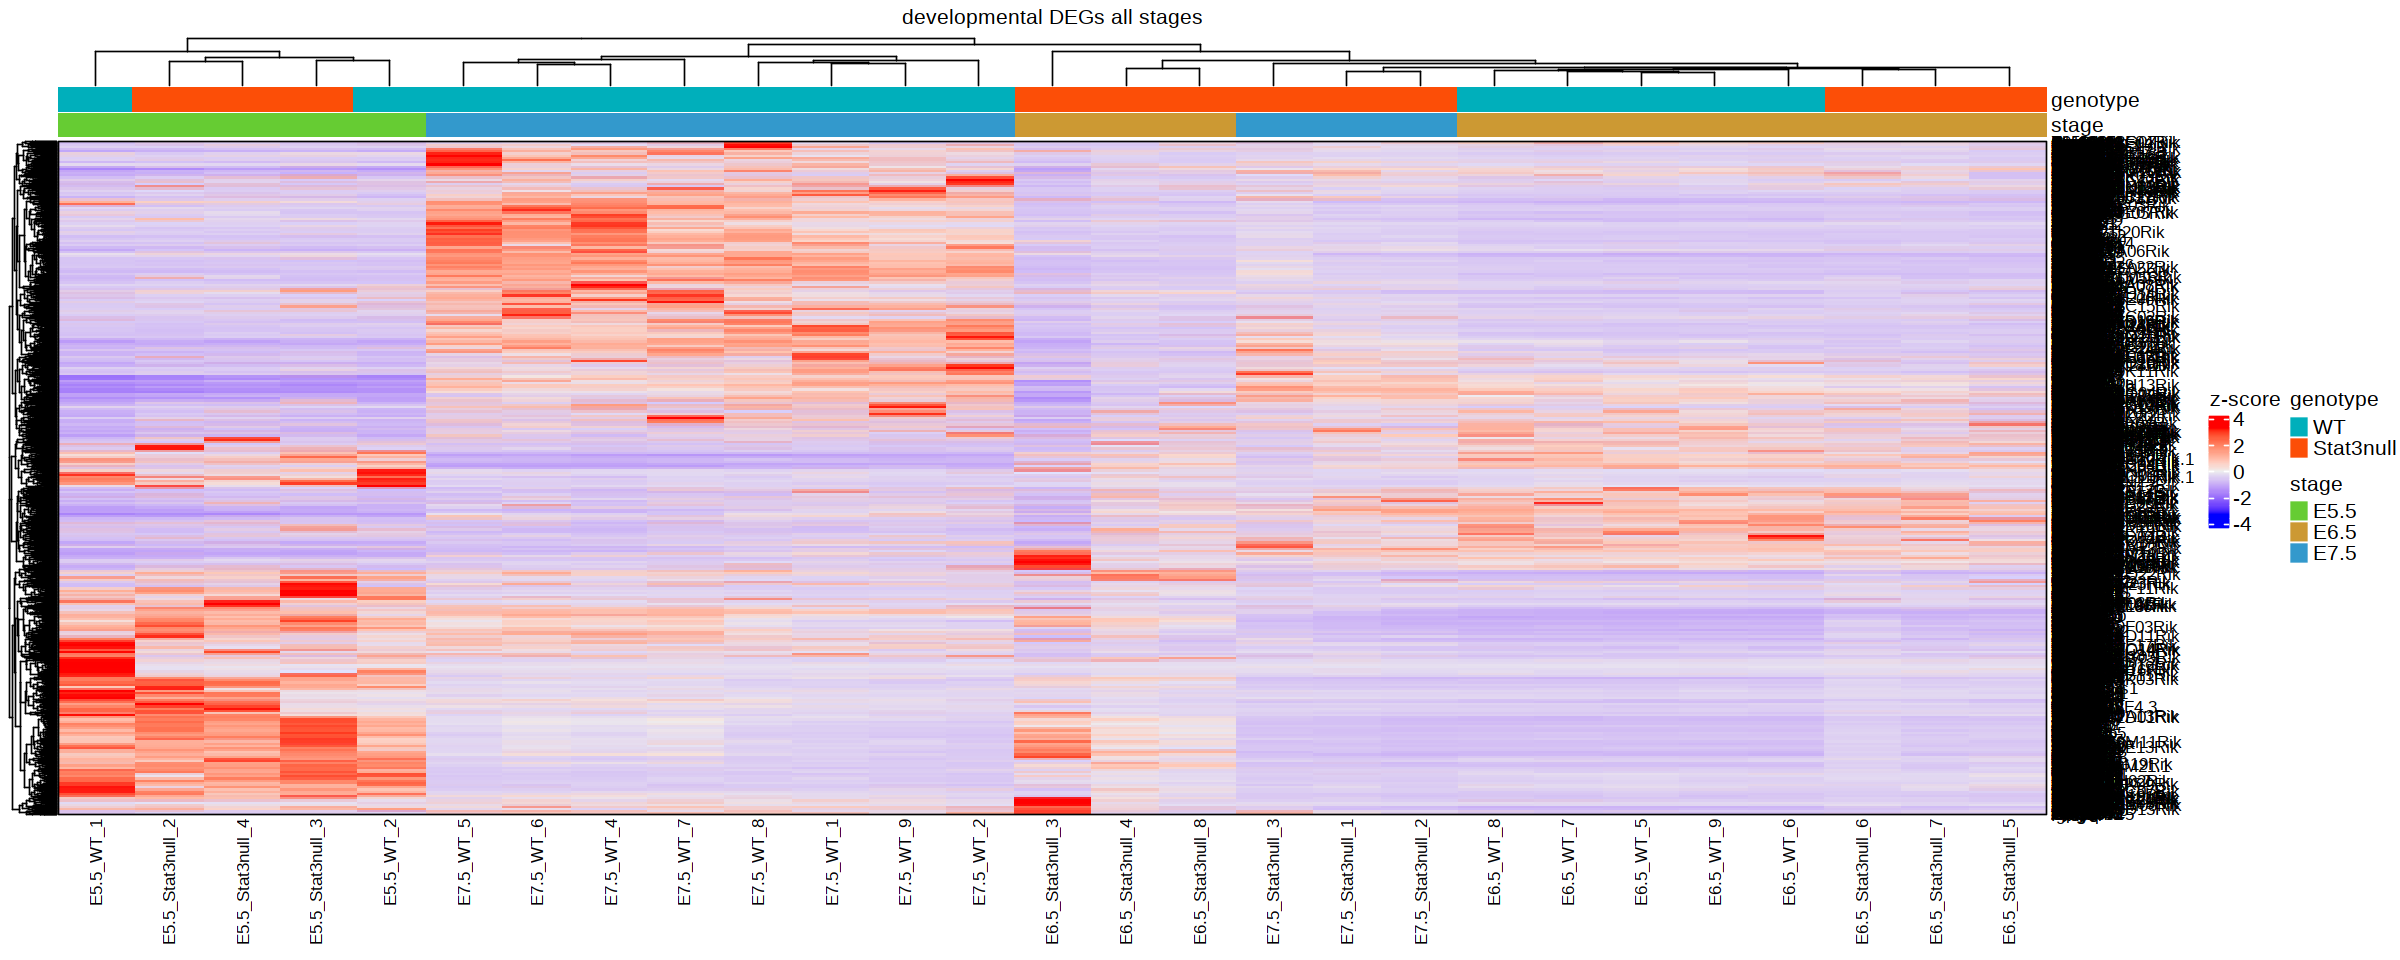

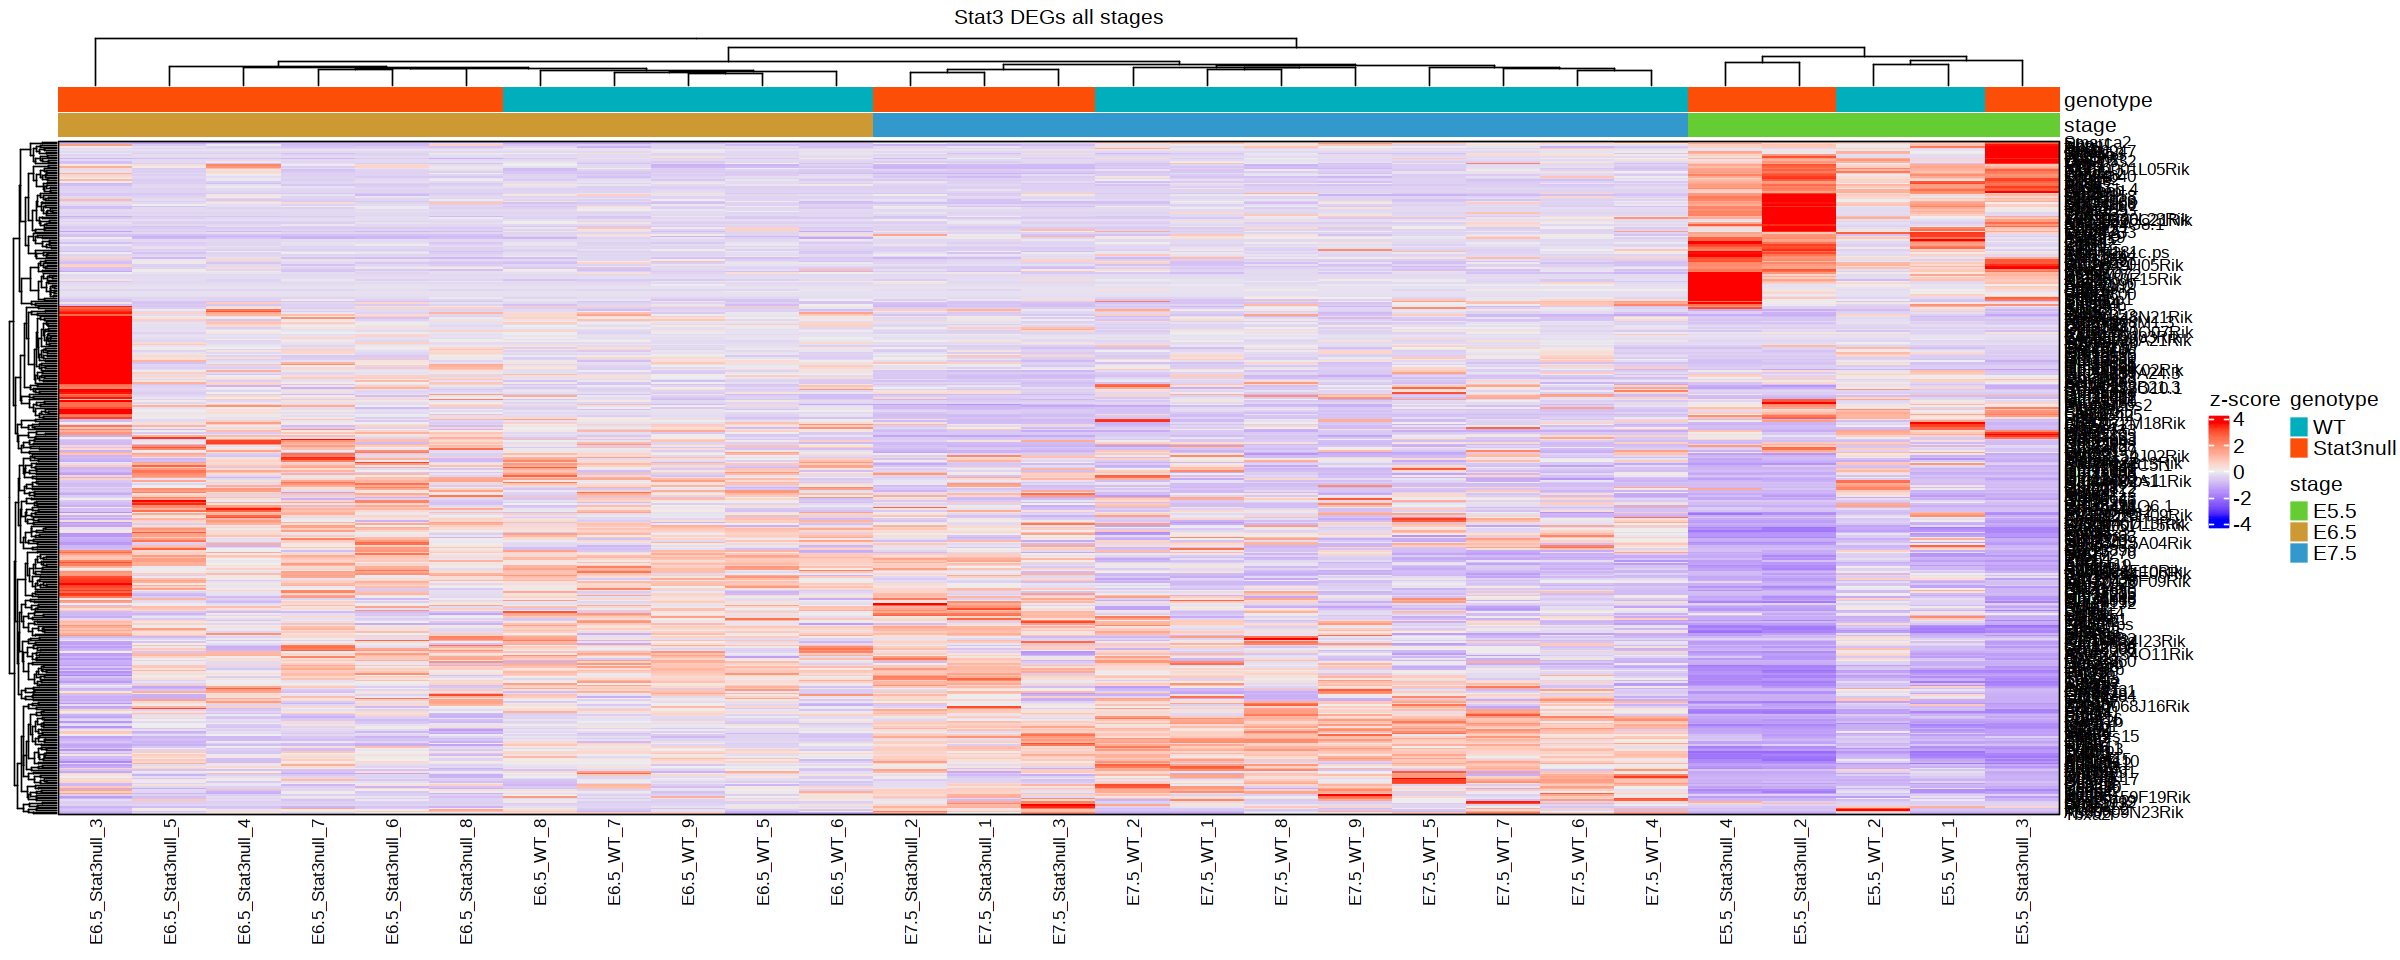

In [562]:
# DEGs of development and Stat3 specific across all samples
plot_heatmap(development_genes, title='developmental DEGs all stages')
plot_heatmap(stat3_specific, title='Stat3 DEGs all stages')

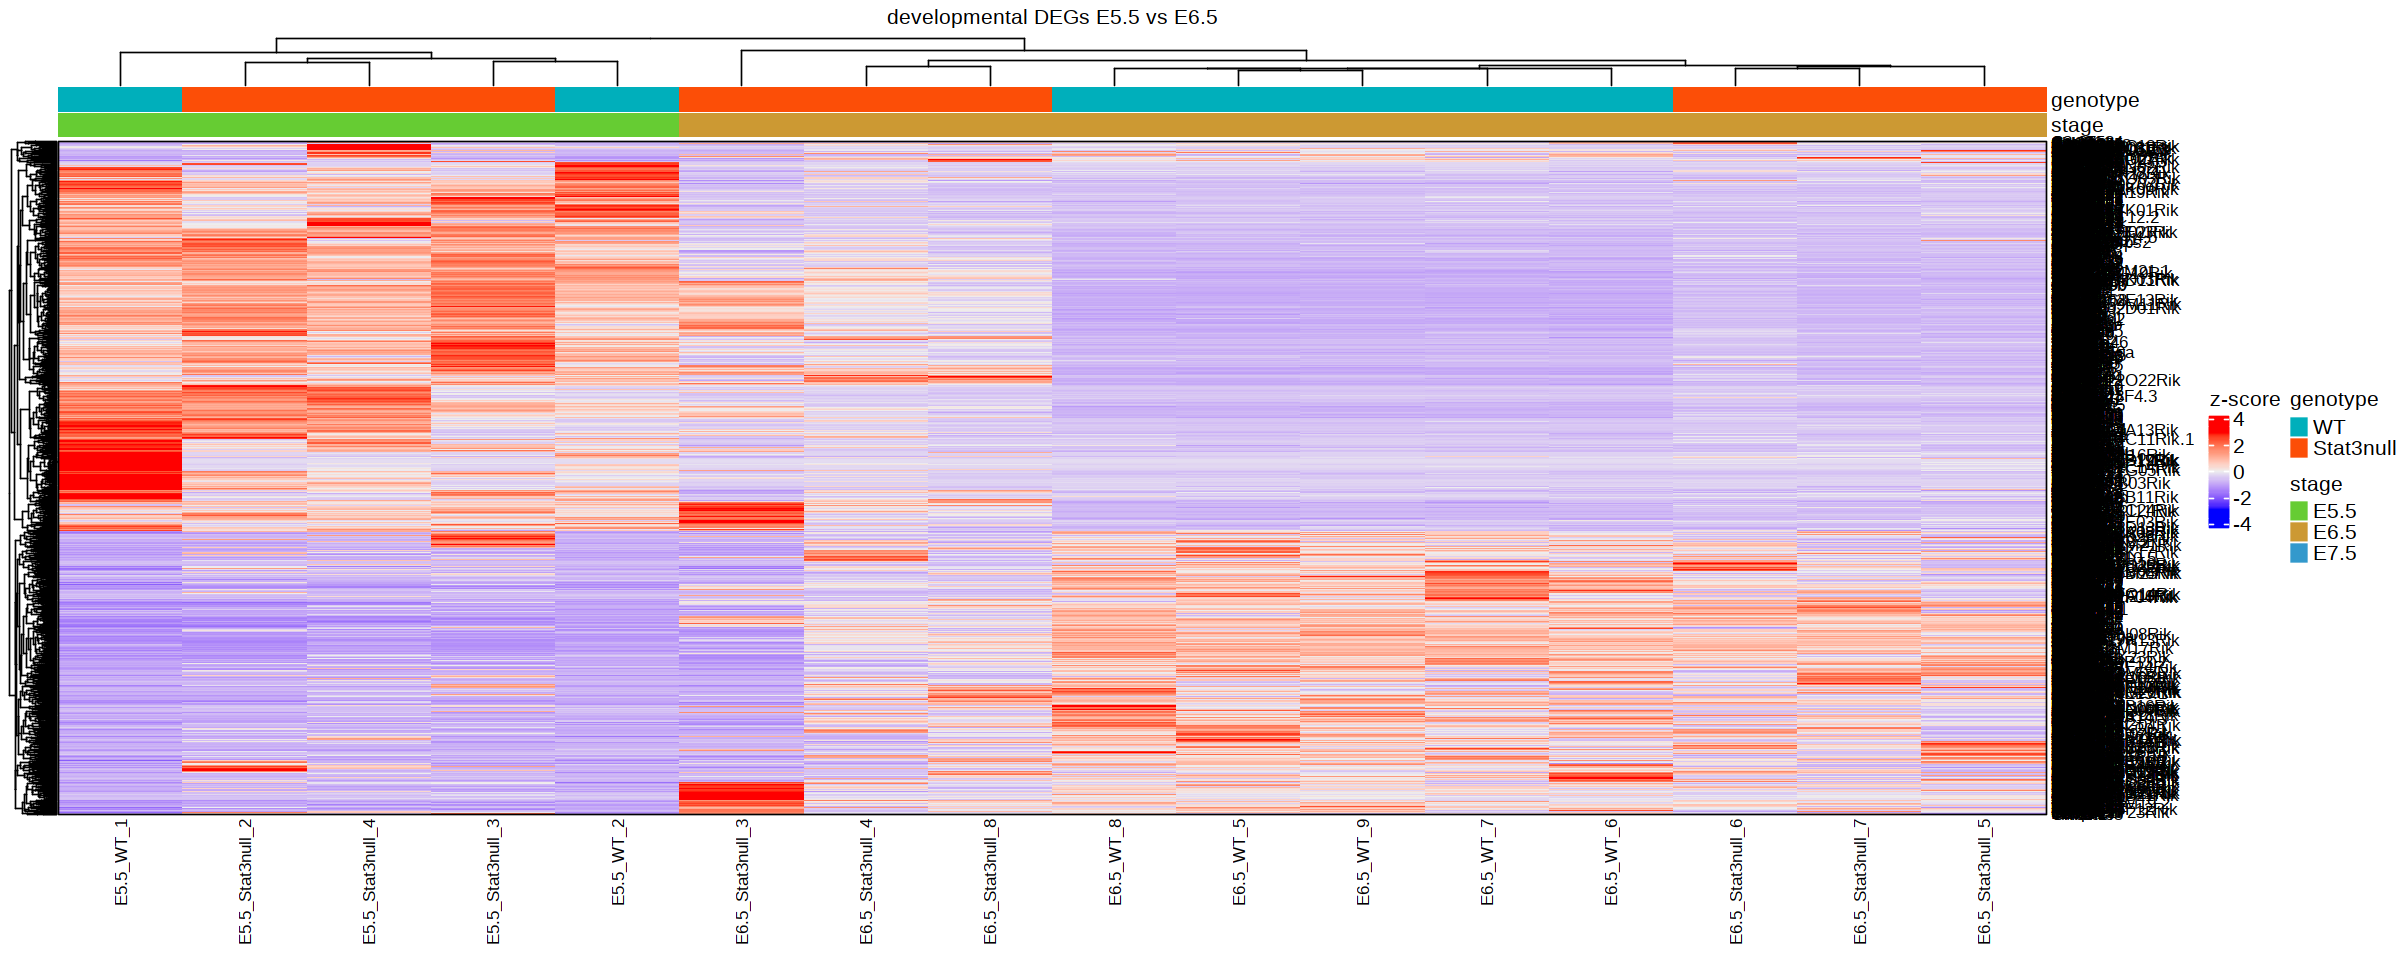

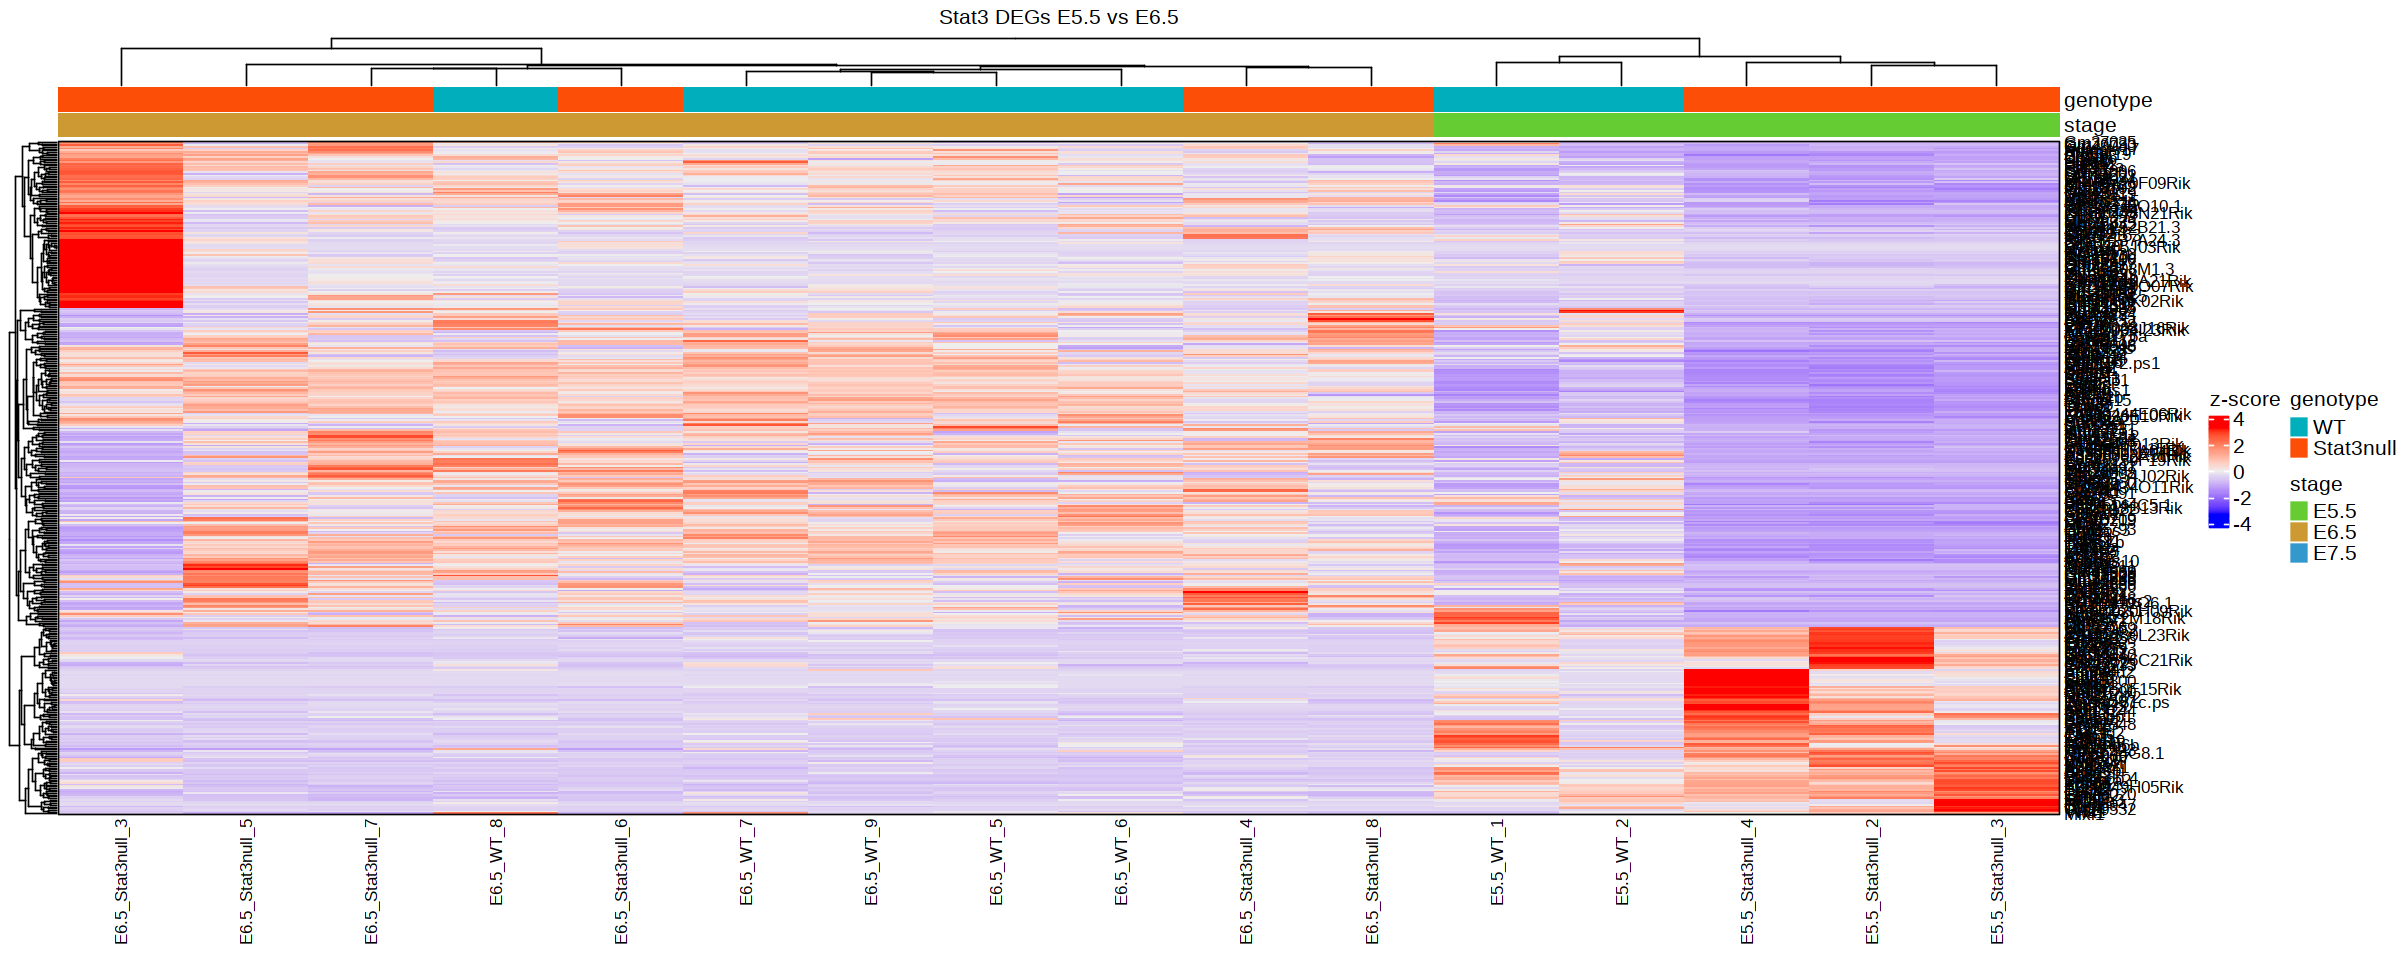

In [47]:
# DEGs between E5.5 & E6.5
samples_i = colData[group %in% c('Stat3null_E6.5','Stat3null_E5.5','WT_E6.5','WT_E5.5'), sample]

stat3_specific_e65e55 = setdiff( stat65_vs_stat55[sig==TRUE, gene], wt65_vs_wt55[sig==TRUE, gene])
dev_specific_e65e55 = wt65_vs_wt55[sig==TRUE, gene]

plot_heatmap(dev_specific_e65e55, samples_i, title='developmental DEGs E5.5 vs E6.5')
plot_heatmap(stat3_specific_e65e55, samples_i, title='Stat3 DEGs E5.5 vs E6.5')


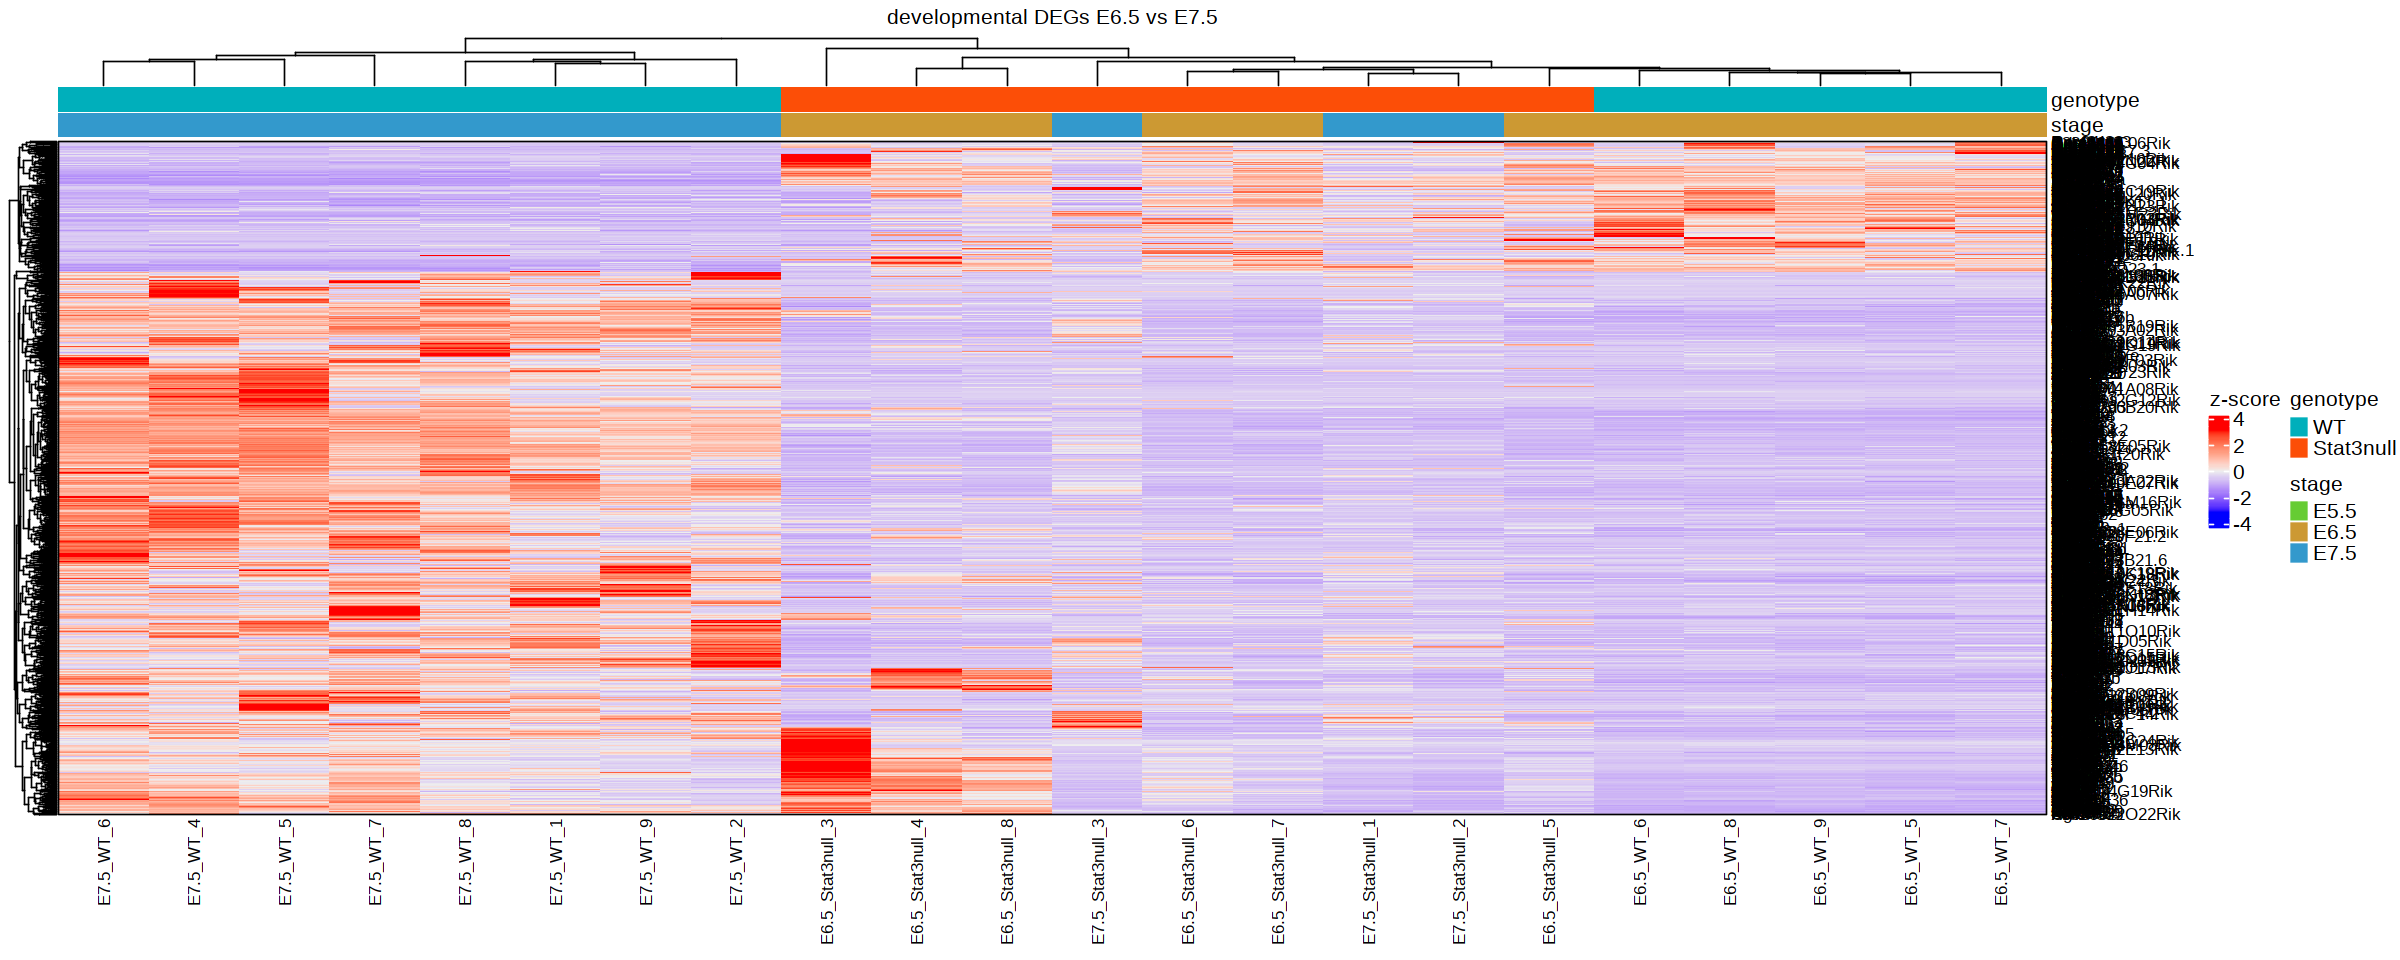

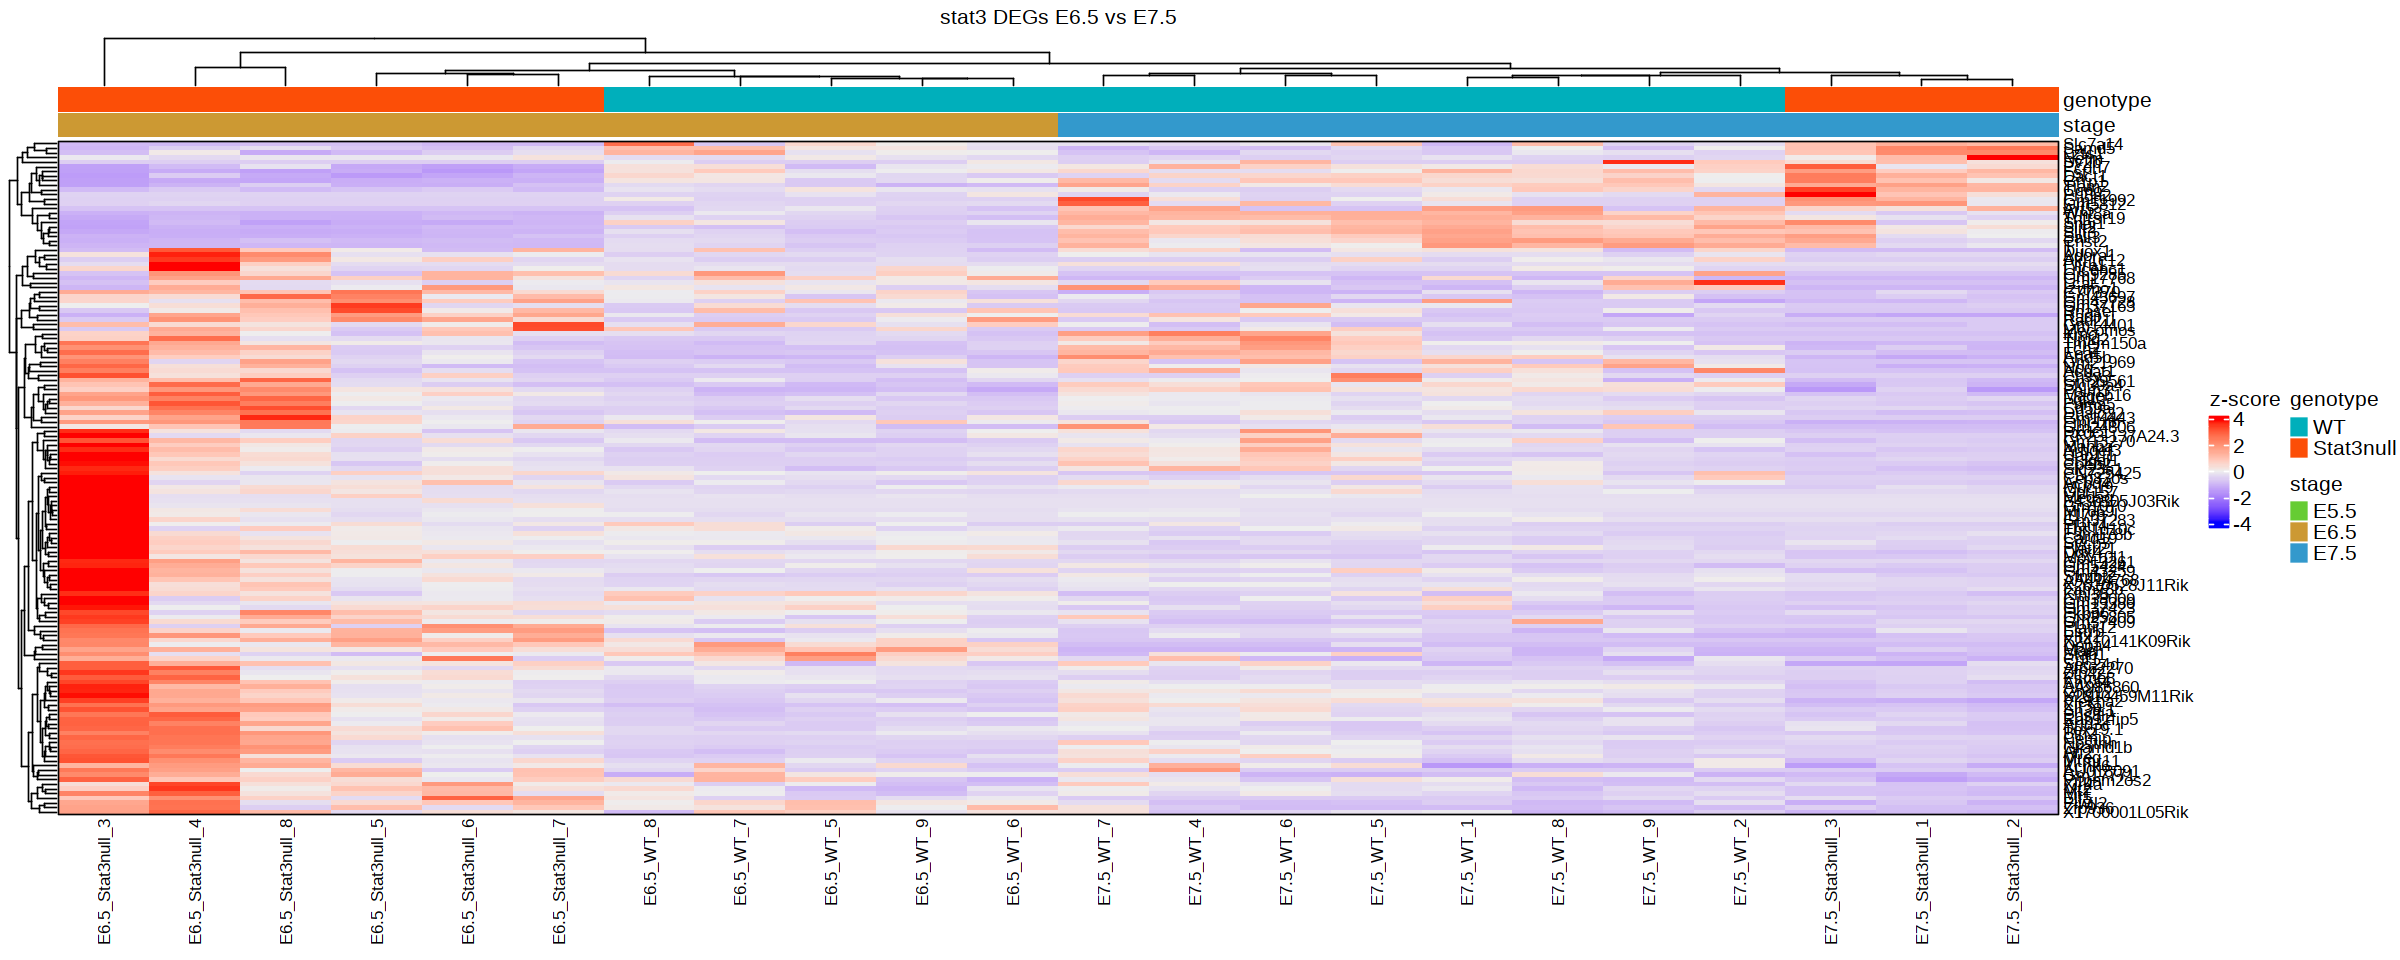

In [48]:
# DEGs between E6.5 & E7.5
samples_i = colData[group %in% c('Stat3null_E7.5','Stat3null_E6.5','WT_E7.5','WT_E6.5'), sample]

stat3_specific_e75e65 = setdiff( stat75_vs_stat65[sig==TRUE, gene], wt75_vs_wt65[sig==TRUE, gene])
dev_specific_e75e65 = wt75_vs_wt65[sig==TRUE, gene]

plot_heatmap(dev_specific_e75e65, samples_i, title='developmental DEGs E6.5 vs E7.5')
plot_heatmap(stat3_specific_e75e65, samples_i, title='stat3 DEGs E6.5 vs E7.5')


In [49]:
# Comparing Sig between E6.5 & E7.5 
wt_vs_stat_65_75 = merge(stat75_vs_stat65[, c('gene', 'log2FoldChange', 'sig')] %>% setnames(c('gene', 'logFC_stat', 'sig_stat')),   
              wt75_vs_wt65[, c('gene', 'log2FoldChange', 'sig')] %>% setnames(c('gene', 'logFC_wt', 'sig_wt')),
                   by='gene', keep.all=TRUE) %>%
                .[,sig:=ifelse(sig_wt==TRUE, 'WT', ifelse(sig_stat==TRUE, 'Stat3', 'not_sig'))] %>%
                .[,sig:=ifelse(sig_wt==TRUE & sig_stat==TRUE, 'both', sig)]

# Comparing Sig between E5.5 & E6.5 
wt_vs_stat_55_65 = merge(stat65_vs_stat55[, c('gene', 'log2FoldChange', 'sig')] %>% setnames(c('gene', 'logFC_stat', 'sig_stat')),   
              wt65_vs_wt55[, c('gene', 'log2FoldChange', 'sig')] %>% setnames(c('gene', 'logFC_wt', 'sig_wt')),
                   by='gene', keep.all=TRUE) %>%
                .[,sig:=ifelse(sig_wt==TRUE, 'WT', ifelse(sig_stat==TRUE, 'Stat3', 'not_sig'))] %>%
                .[,sig:=ifelse(sig_wt==TRUE & sig_stat==TRUE, 'both', sig)]

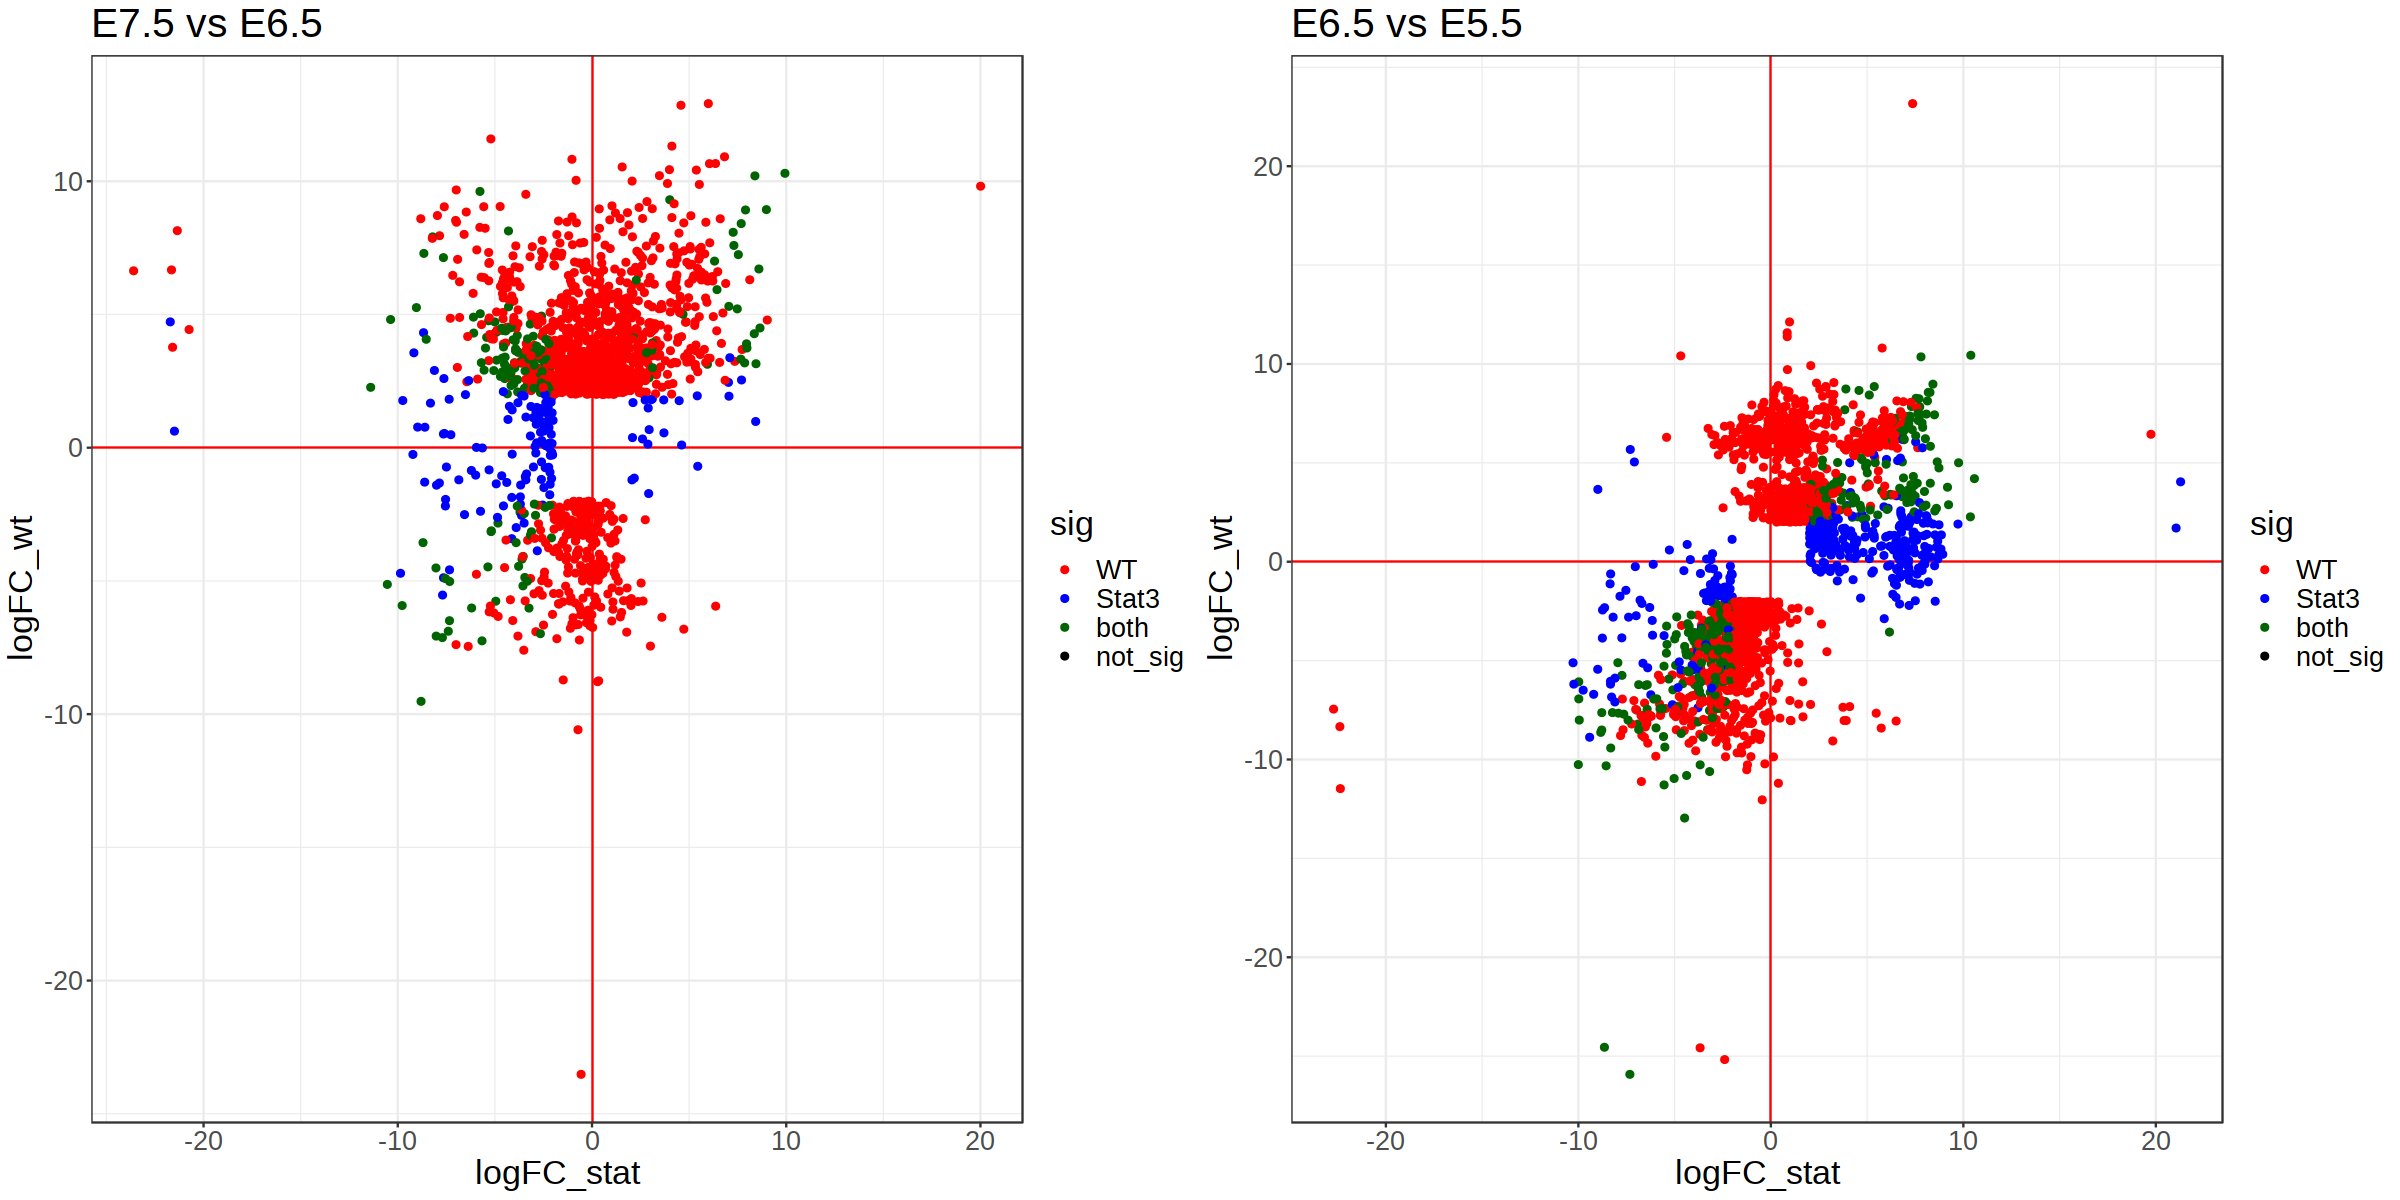

In [50]:
options(repr.plot.width=10, repr.plot.height=10) 

p1 = ggplot(wt_vs_stat_65_75[sig!='not_sig'], aes(logFC_stat, logFC_wt, col=sig)) + 
    geom_hline(yintercept=0, color='red') + 
    geom_vline(xintercept=0, color='red') + 
    geom_point() + 
    scale_color_manual(values=c('WT'='darkred',
                                'Stat3'='darkblue',
                                'both'='darkgreen',
                                'not_sig'='black')) +
    ggtitle('E7.5 vs E6.5') +
    theme_bw() + theme(text=element_text(size=20, color='black'))

p2 = ggplot(wt_vs_stat_55_65[sig!='not_sig'], aes(logFC_stat, logFC_wt, col=sig)) + 
    geom_hline(yintercept=0, color='red') + 
    geom_vline(xintercept=0, color='red') + 
    geom_point() + 
    scale_color_manual(values=c('WT'='darkred',
                                'Stat3'='darkblue',
                                'both'='darkgreen',
                                'not_sig'='black')) +
    ggtitle('E6.5 vs E5.5') +
    theme_bw() + theme(text=element_text(size=20, color='black'))

options(repr.plot.width=20, repr.plot.height=10) 
ggarrange(p1, p2, ncol=2, legend='right')

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



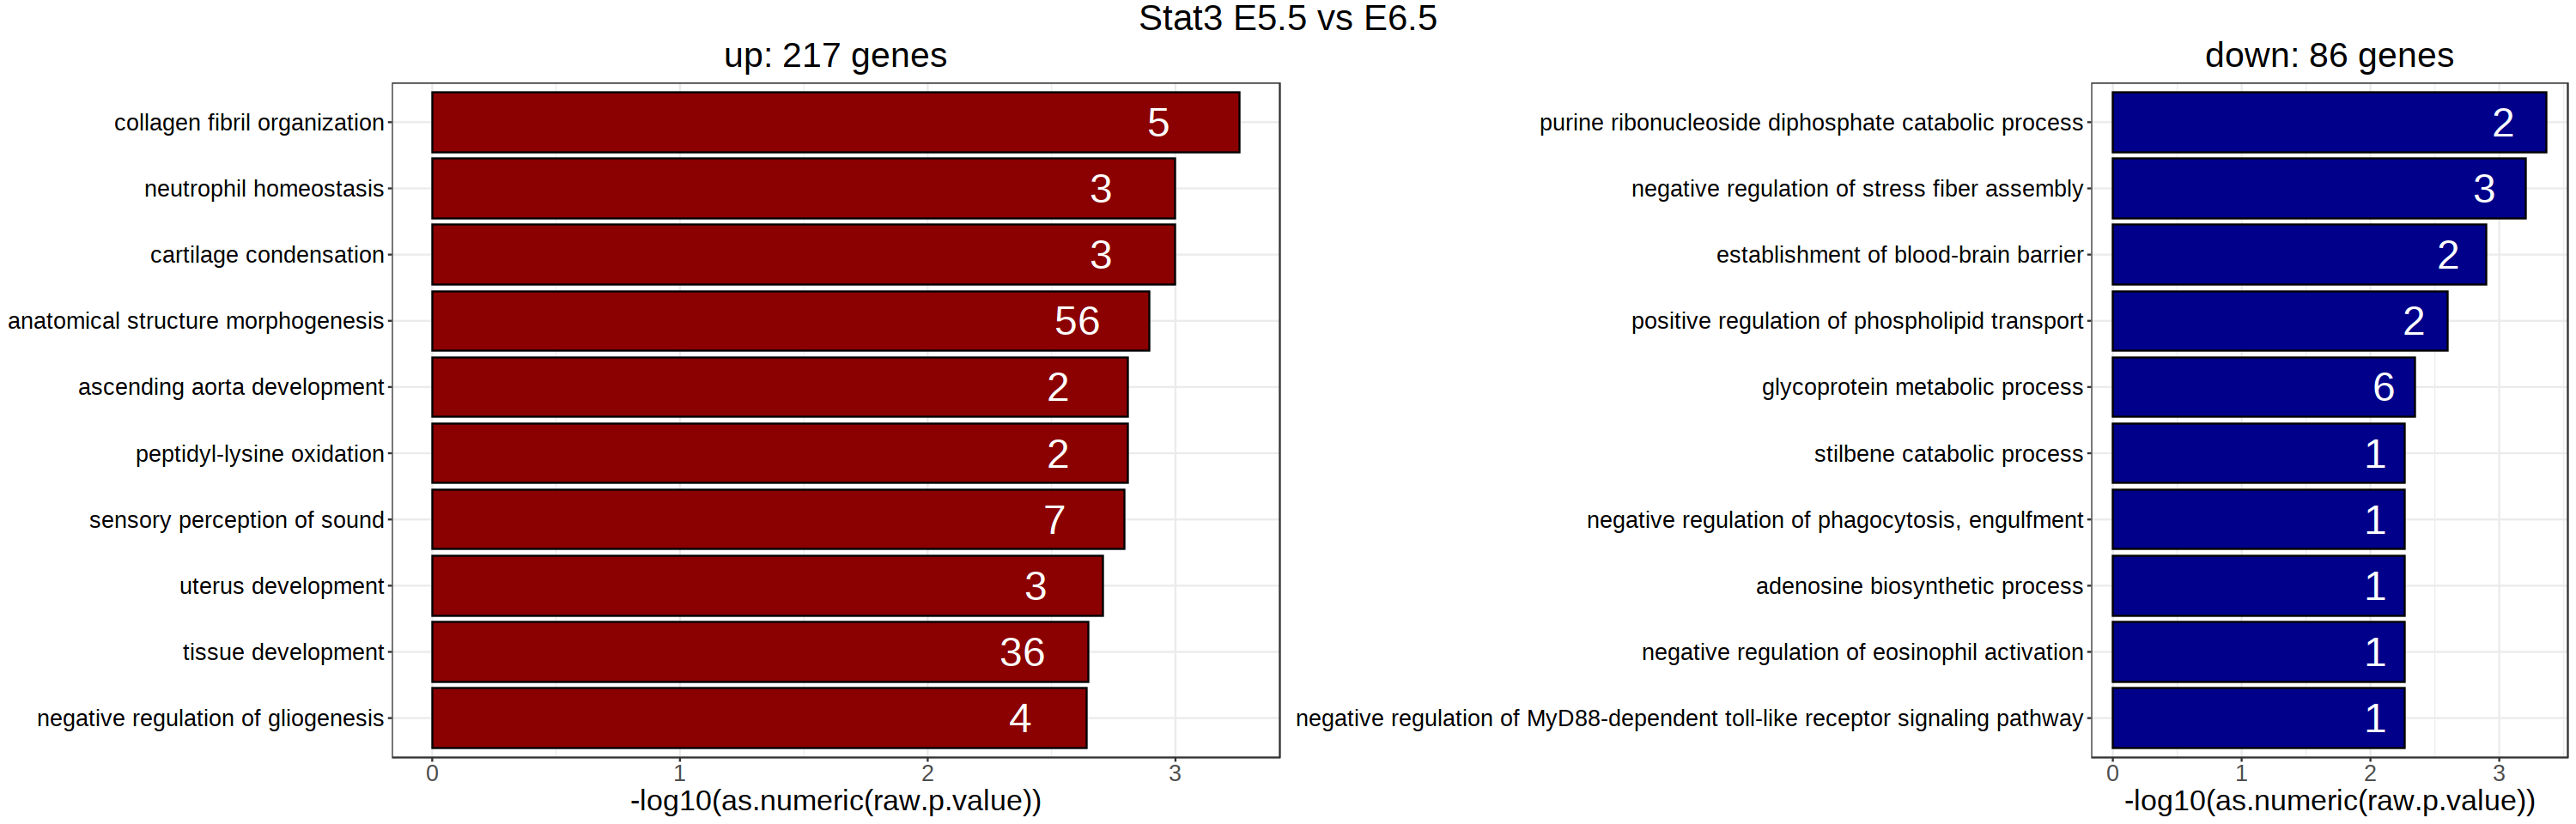

'select()' returned 1:1 mapping between keys and columns



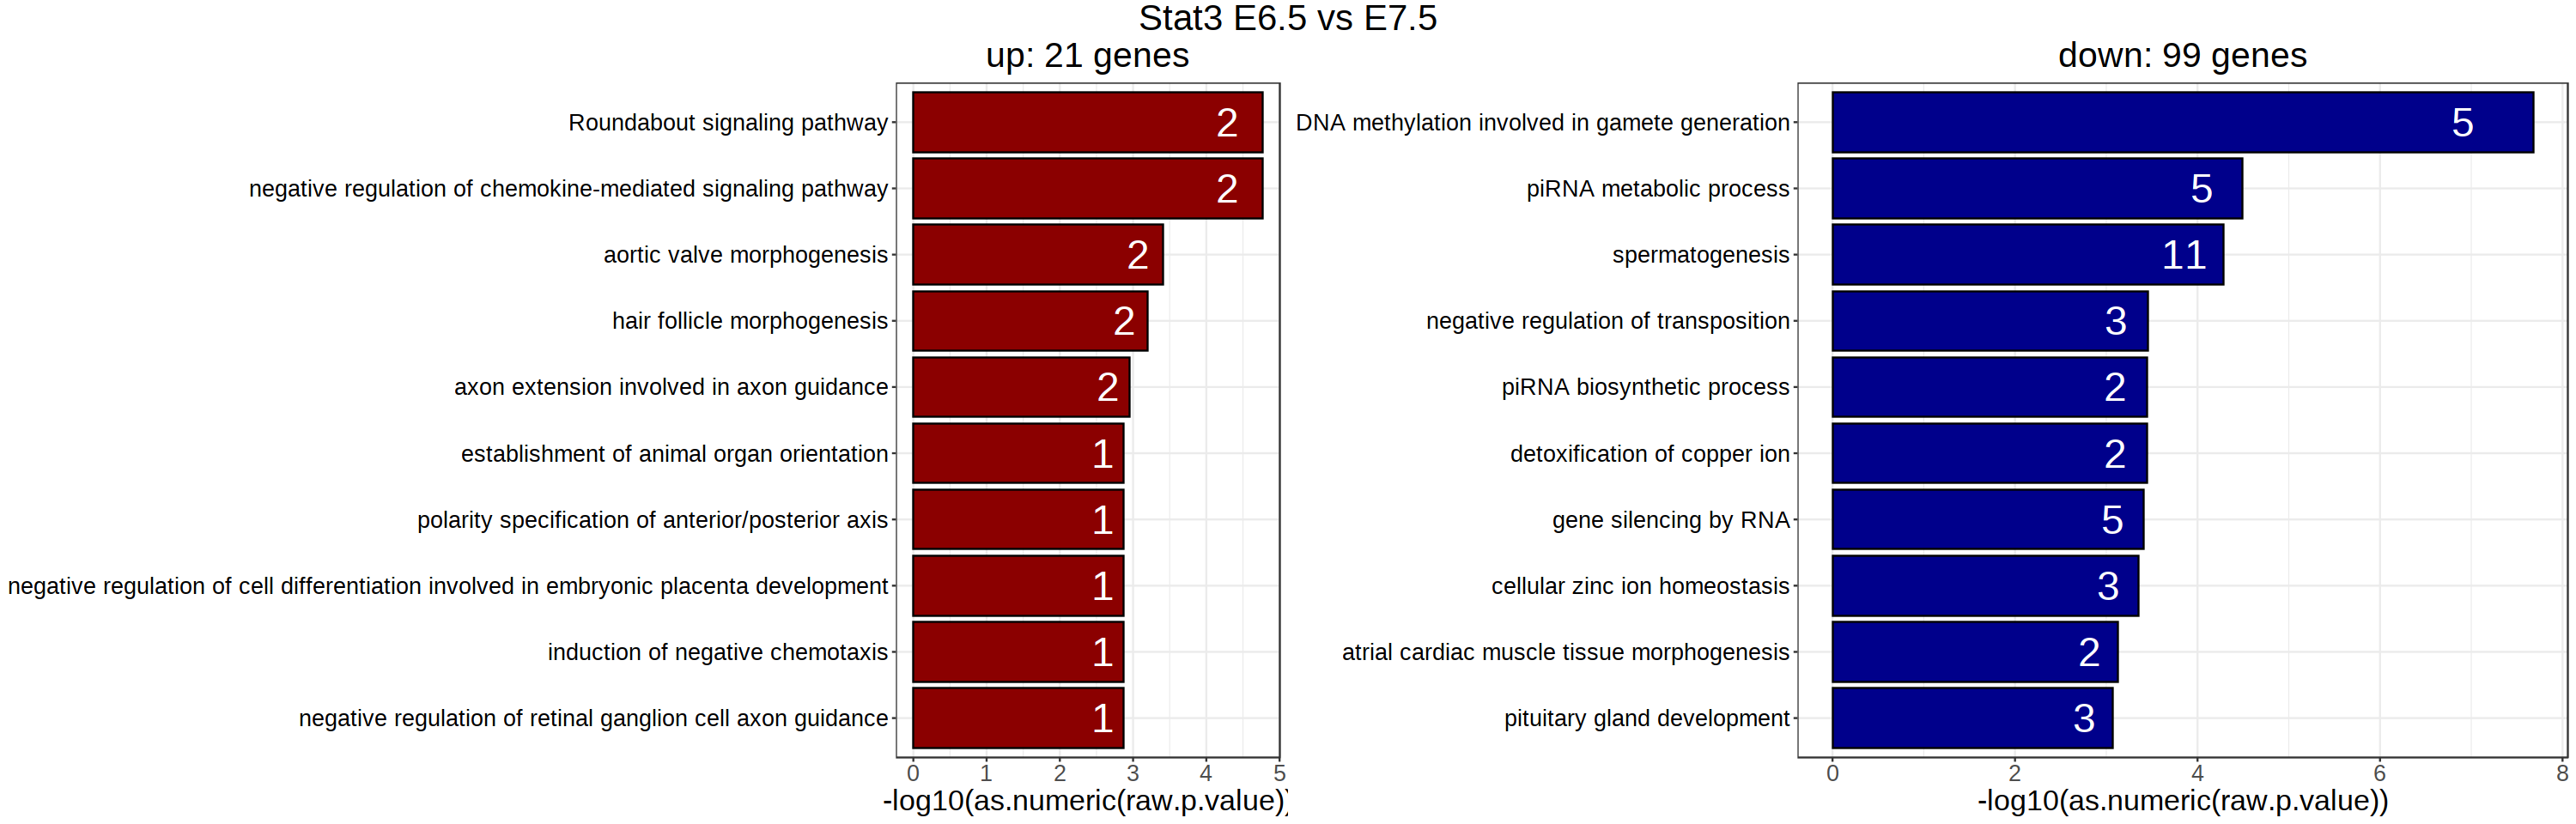

'select()' returned 1:1 mapping between keys and columns



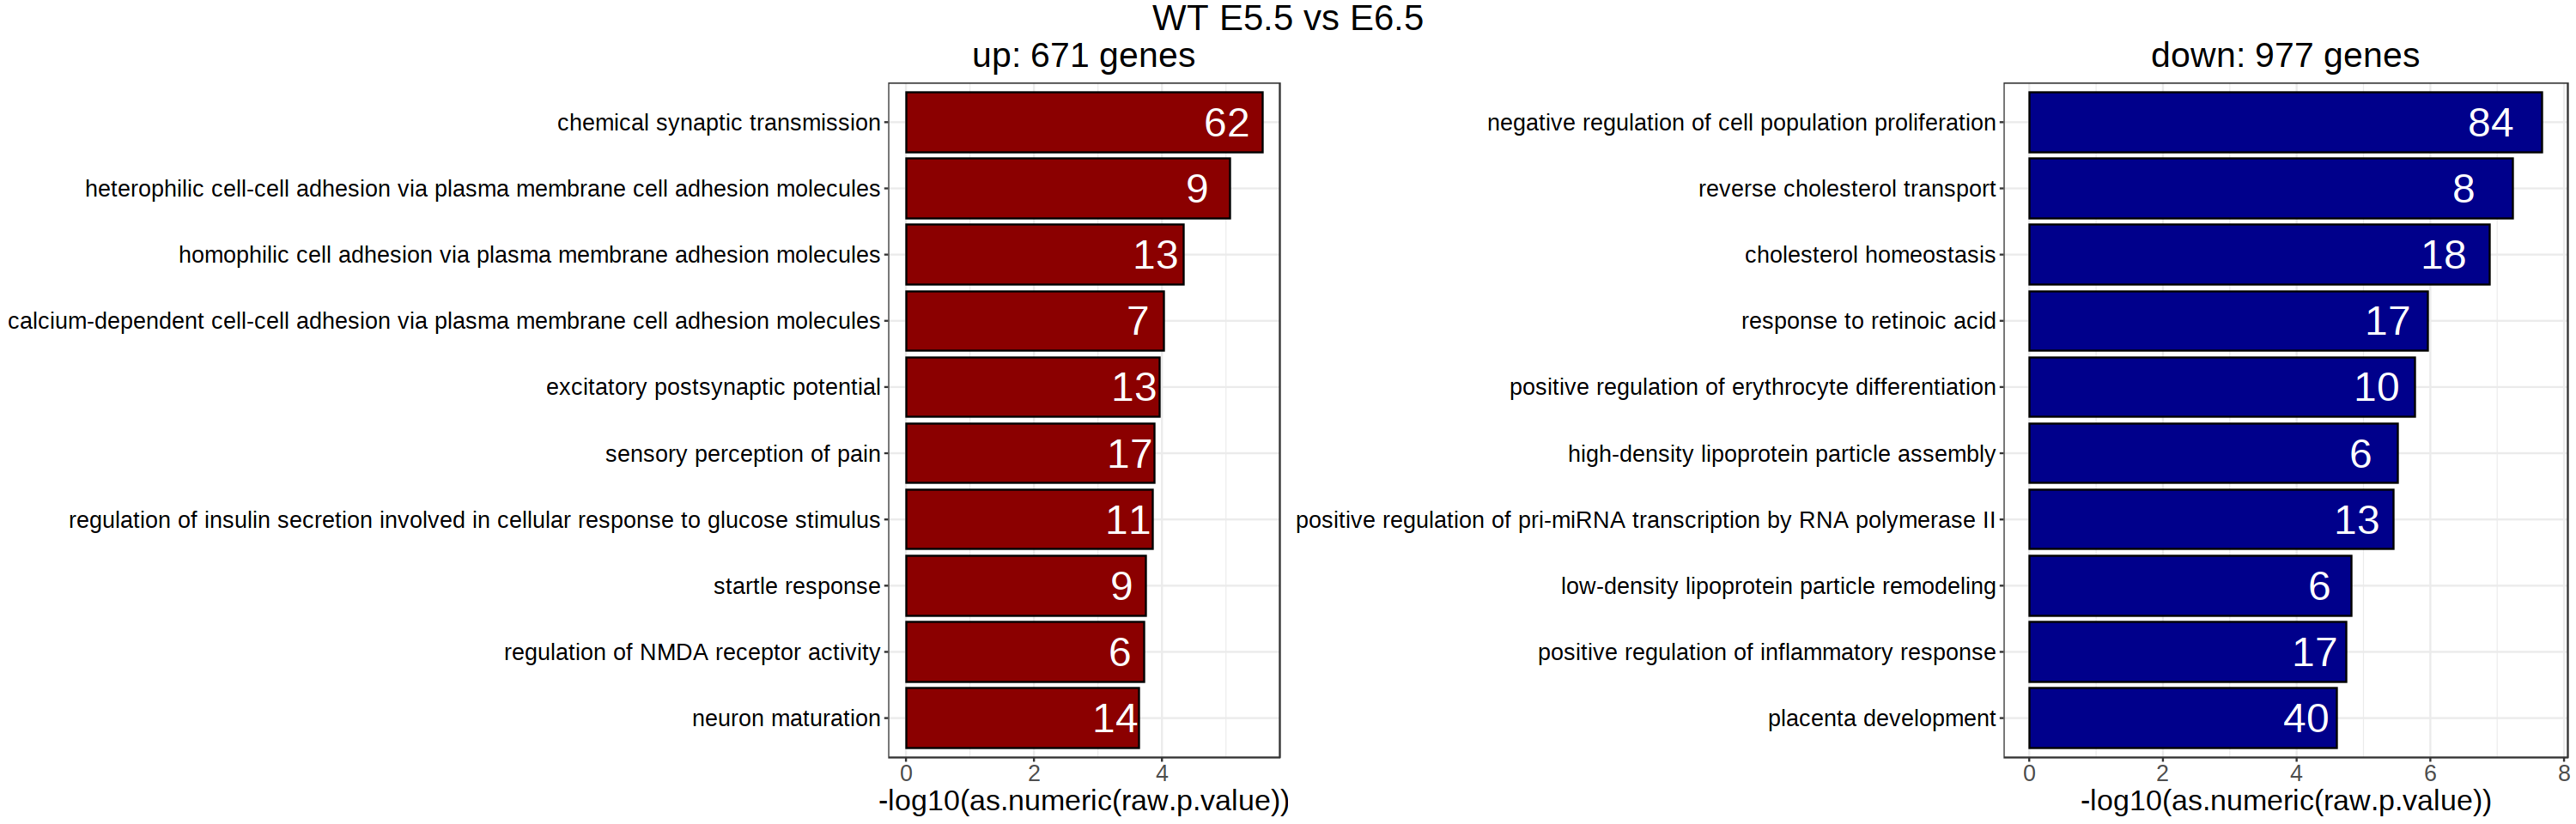

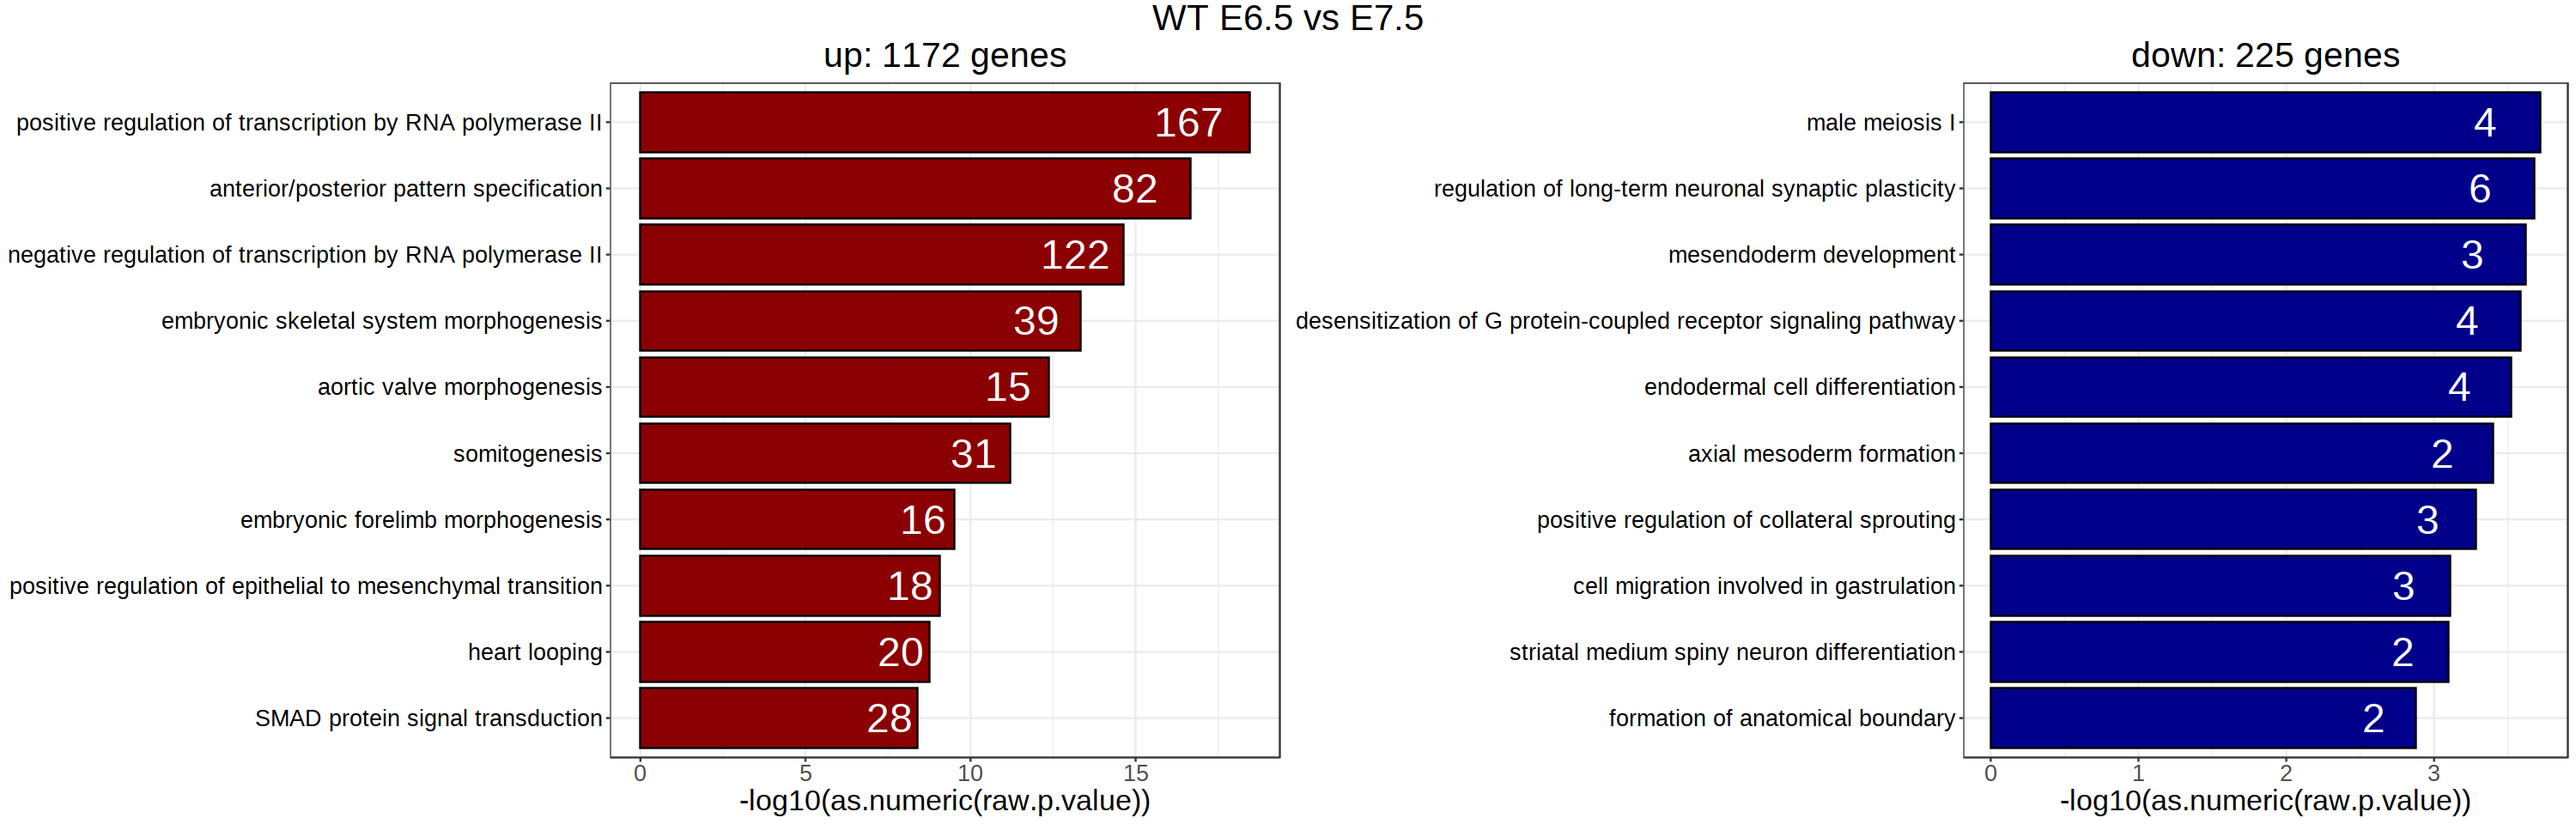

In [68]:
### Ontology = Biological Process Function (BP)

# GO of Stat3 specific genes at E5.5 vs E6.5

test = wt_vs_stat_55_65 %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig=='Stat3' & logFC_stat>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig=='Stat3' & logFC_stat<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='Stat3 E5.5 vs E6.5', ont='BP'))

# GO of Stat3 specific genes at E6.5 vs E7.5
test = wt_vs_stat_65_75 %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig=='Stat3' & logFC_stat>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig=='Stat3' & logFC_stat<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='Stat3 E6.5 vs E7.5', ont='BP'))

# GO of development specific genes at E5.5 vs E6.5
test = wt65_vs_wt55 %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig==TRUE & log2FoldChange>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig==TRUE & log2FoldChange<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='WT E5.5 vs E6.5', ont='BP'))

# GO of development specific genes at E6.5 vs E7.5
test = wt75_vs_wt65 %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig==TRUE & log2FoldChange>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig==TRUE & log2FoldChange<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='WT E6.5 vs E7.5', ont='BP'))

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



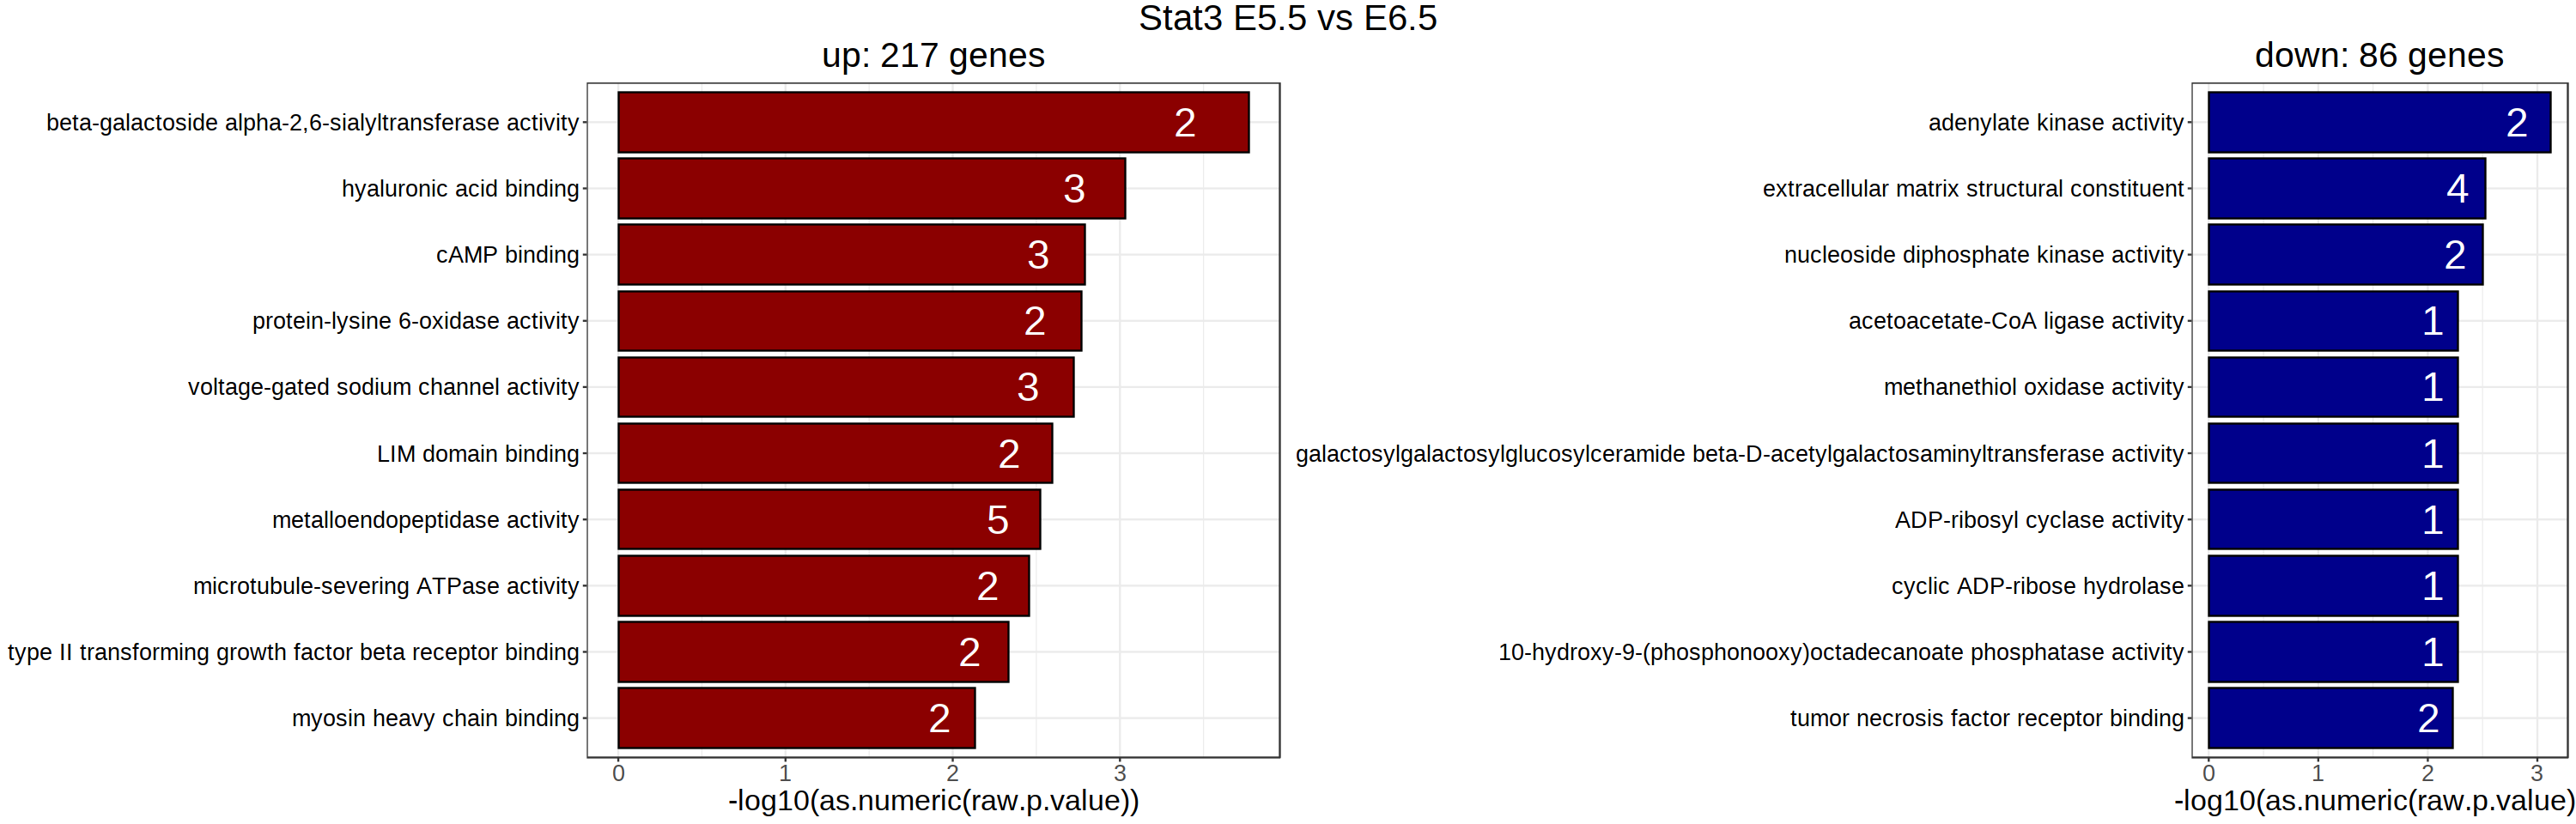

'select()' returned 1:1 mapping between keys and columns



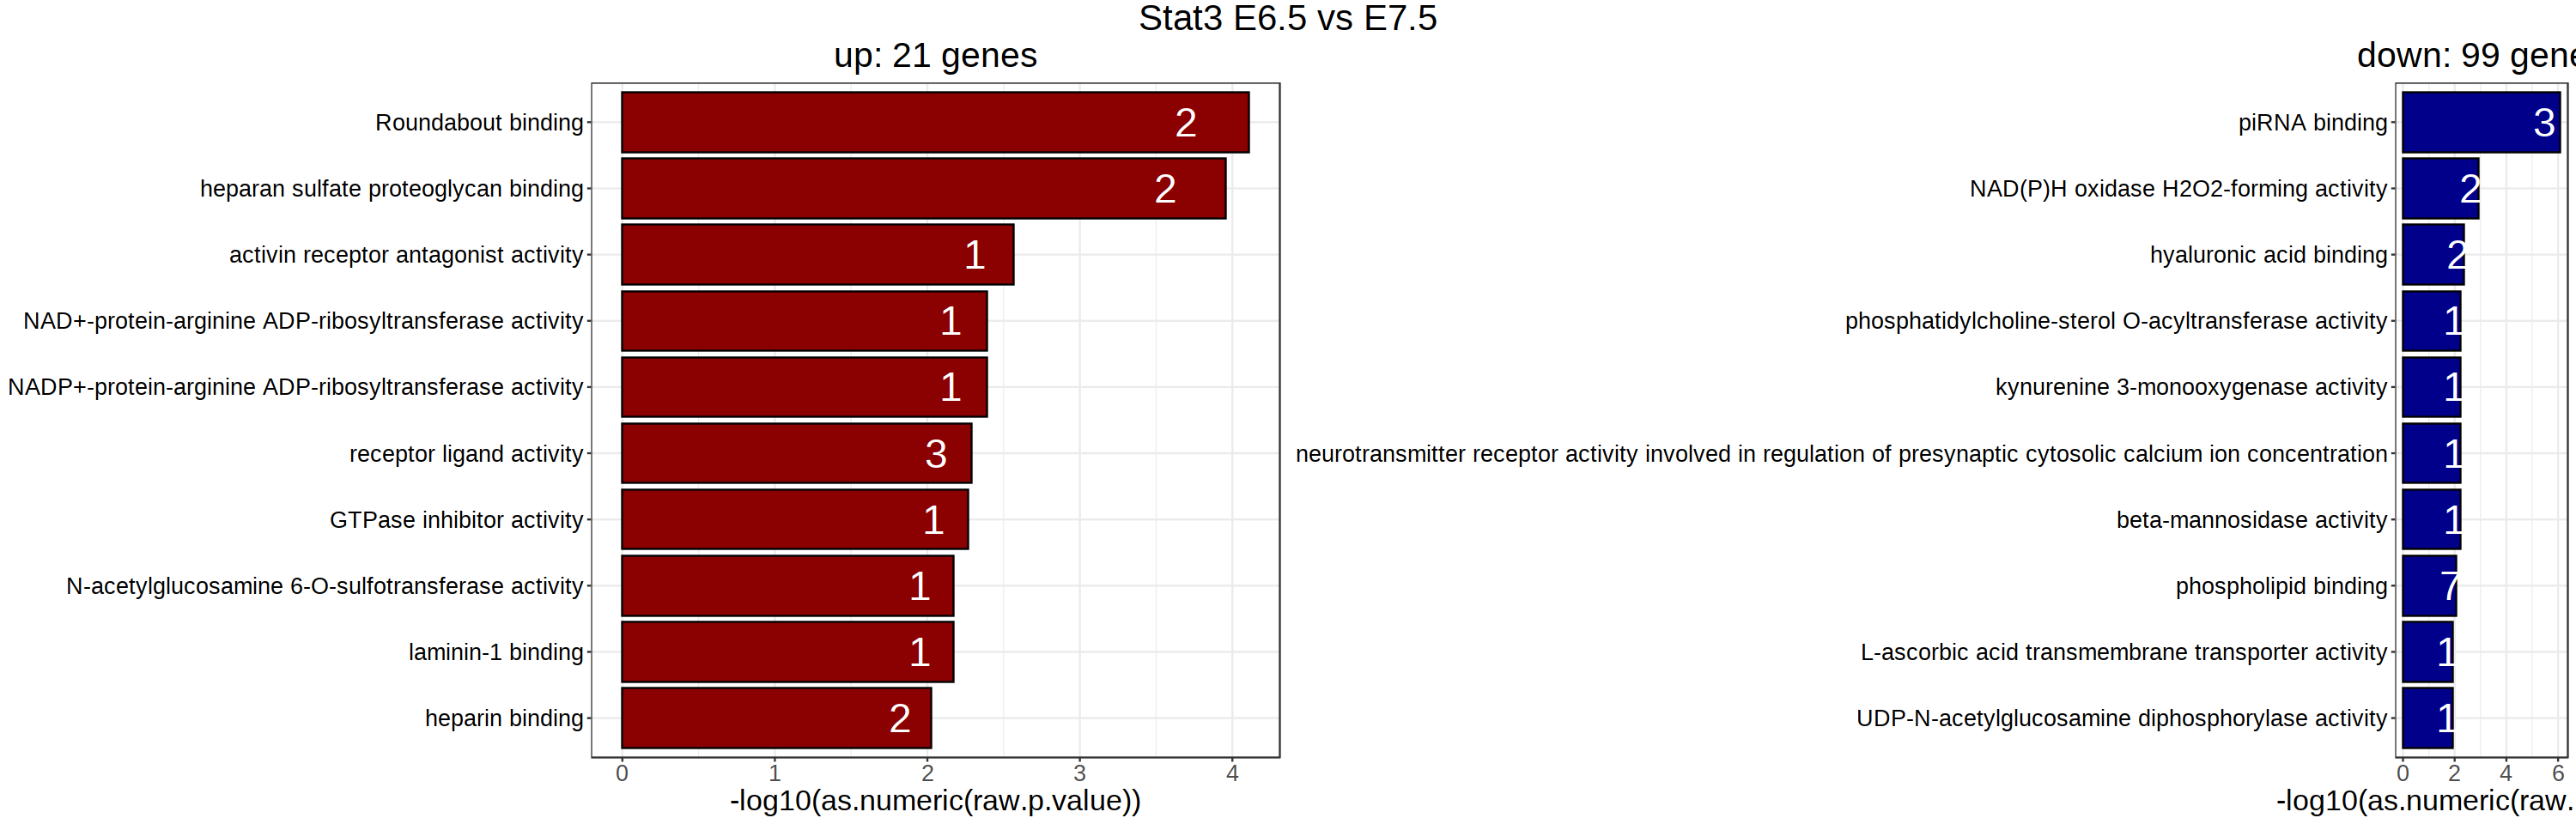

'select()' returned 1:1 mapping between keys and columns



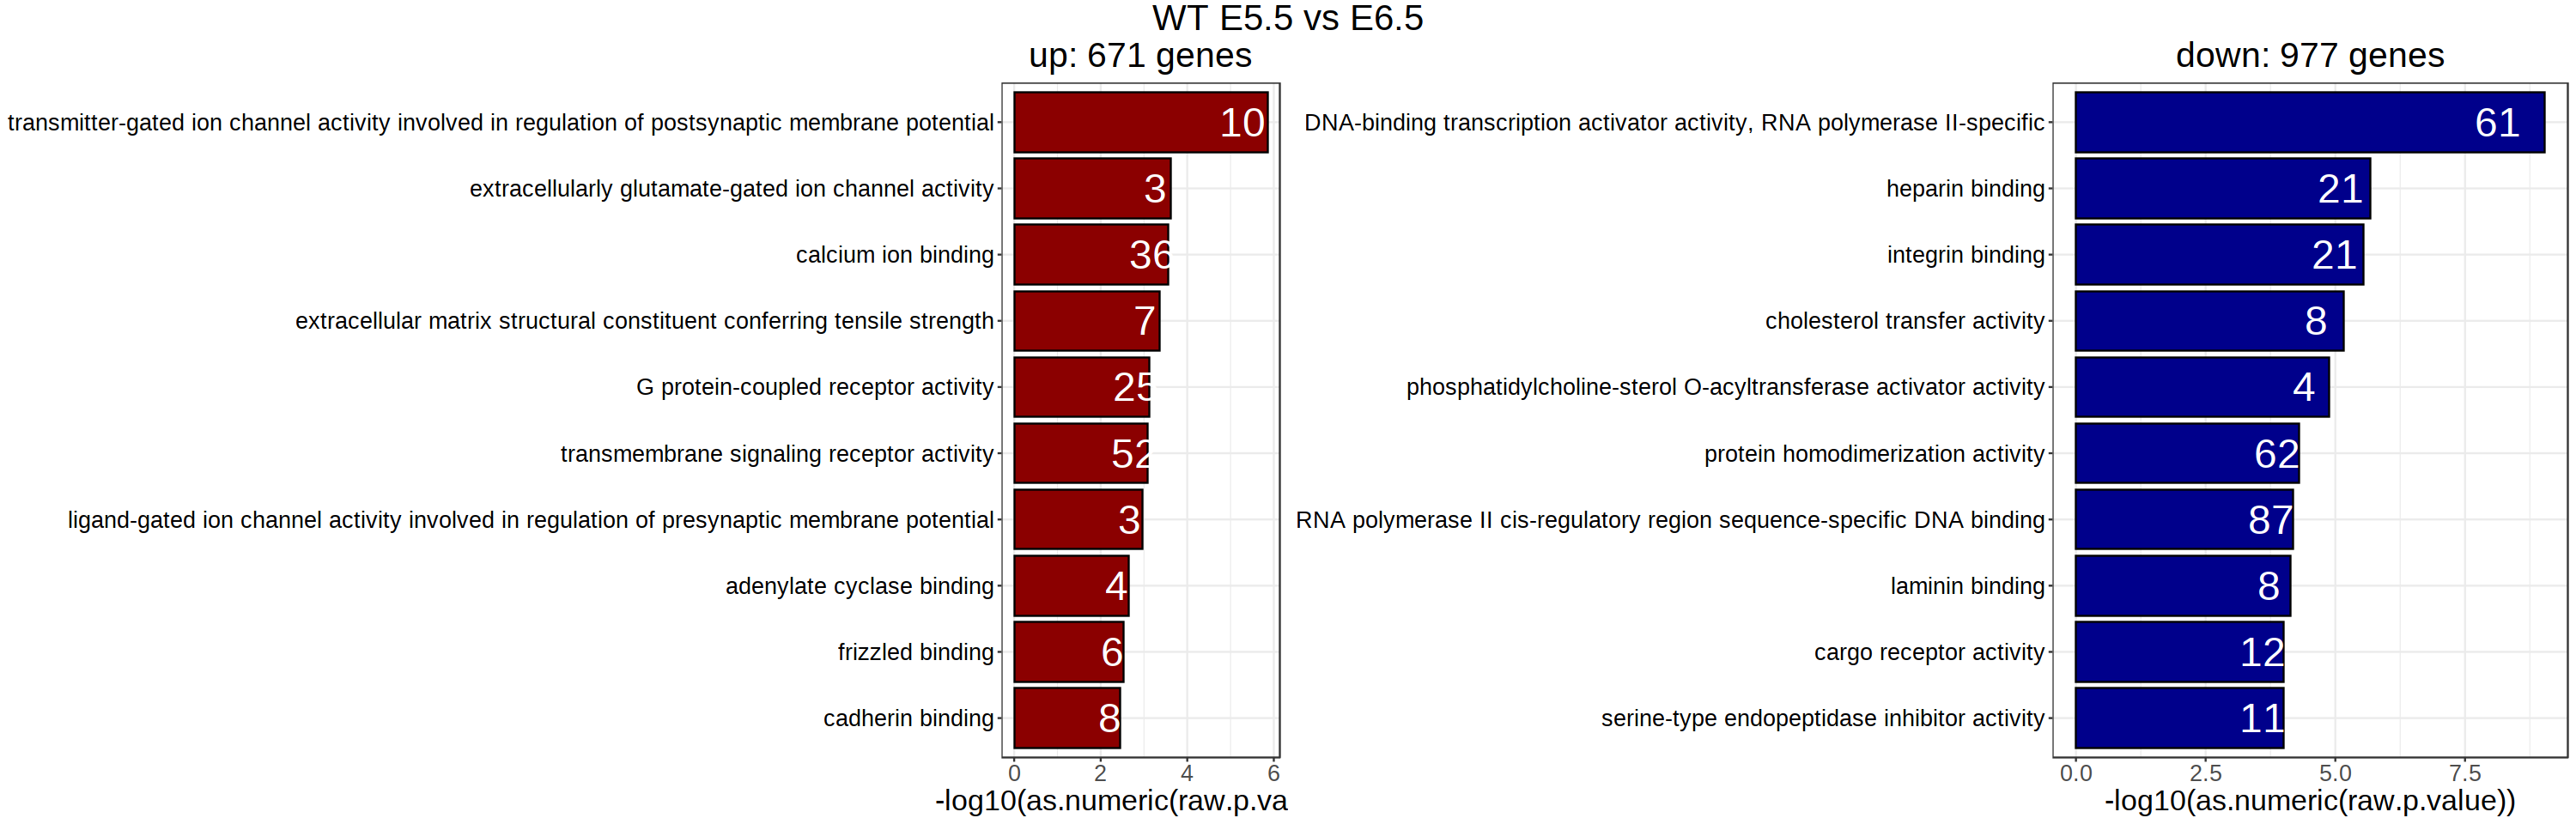

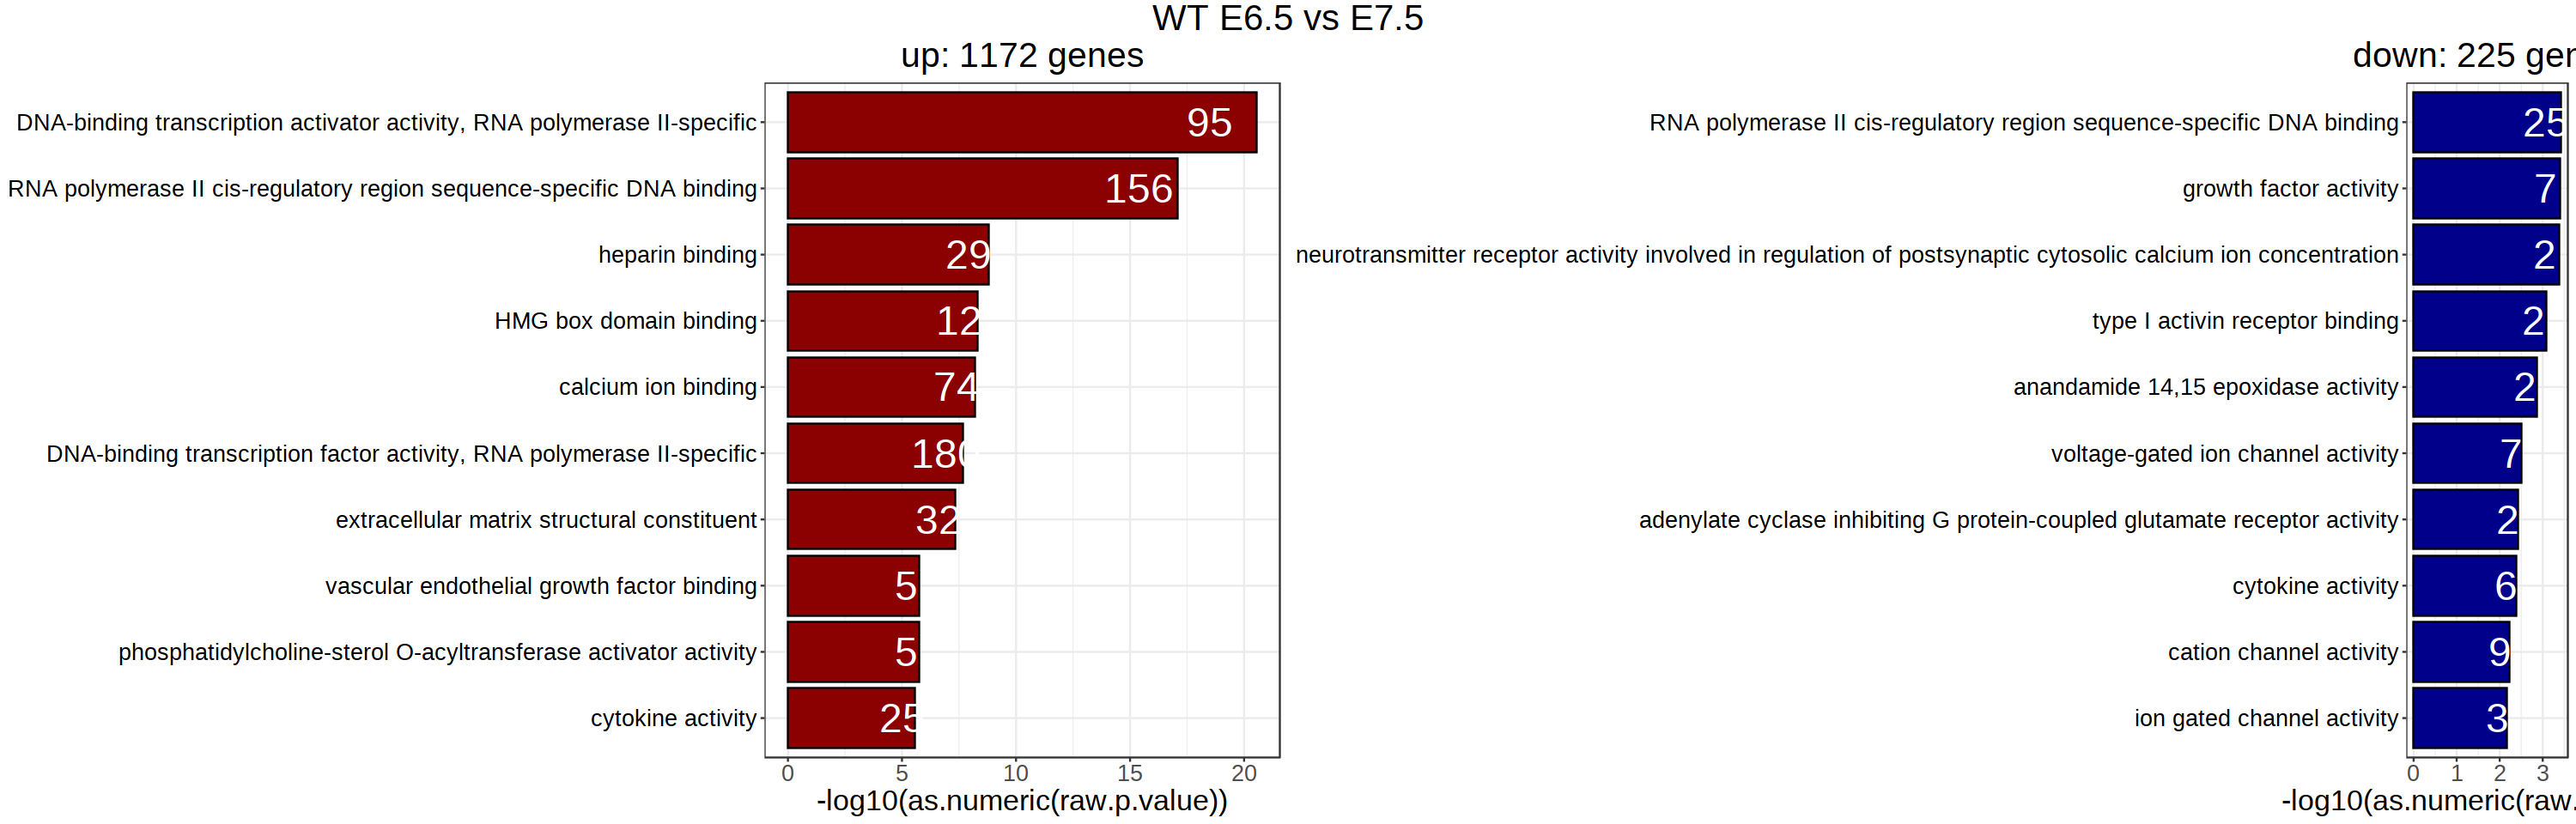

In [67]:
### Ontology = Molecular Function (MF) 

# GO of Stat3 specific genes at E5.5 vs E6.5

test = wt_vs_stat_55_65 %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig=='Stat3' & logFC_stat>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig=='Stat3' & logFC_stat<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='Stat3 E5.5 vs E6.5', ont='MF'))

# GO of Stat3 specific genes at E6.5 vs E7.5
test = wt_vs_stat_65_75 %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig=='Stat3' & logFC_stat>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig=='Stat3' & logFC_stat<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='Stat3 E6.5 vs E7.5', ont='MF'))

# GO of development specific genes at E5.5 vs E6.5
test = wt65_vs_wt55 %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig==TRUE & log2FoldChange>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig==TRUE & log2FoldChange<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='WT E5.5 vs E6.5', ont='MF'))

# GO of development specific genes at E6.5 vs E7.5
test = wt75_vs_wt65 %>%
        .[,entrez:=  mapIds(org.Mm.eg.db, gene, 'ENTREZID', 'SYMBOL')] %>%
        .[!is.na(entrez)] %>% 
        .[,sig_up:=ifelse(sig==TRUE & log2FoldChange>0, 1, 0)] %>%
        .[,sig_down:=ifelse(sig==TRUE & log2FoldChange<0, 1, 0)]
up = test$sig_up
names(up) = test$entrez
down = test$sig_down
names(down) = test$entrez
suppressMessages(plot_go(up, down, title='WT E6.5 vs E7.5', ont='MF'))